# Project Tape-out

# Semilogo OGUNGBURE

## Design Concept: Thermally Tunable Vernier Ring Resonator Filter

## 1.  Introduction

### Project Overview

The objective of this project is the design and analysis of a **thermally tunable Vernier ring resonator filter** implemented on the **PRG e-beam Silicon Nitride (SiN) photonics platform**.

## 2. Design Concept and Theory
### Circuit Topology

The implemented circuit consists of two mutually bus-coupled microring resonators with deliberately mismatched optical path lengths to exploit the Vernier effect. In this topology, each ring acts as a coupling bus for the other, forming a closed-loop optical coupling configuration rather than a simple series cascade. Each microring resonator is integrated with an individual titanium thermo-optic phase shifter, allowing independent thermal tuning of the resonance condition of each ring. The mutual coupling of the two resonators produces a periodic super-resonance envelope with an effective free spectral range (FSR) significantly larger than that of a single microring resonator, thereby enhancing wavelength selectivity.

### Mathematical Basis for Vernier Design

The spectral behavior of the device is governed by the individual Free Spectral Ranges ($FSR$) and the resulting Vernier envelope ($FSR_{\text{Vernier}}$). 

### Individual Ring FSR
The spacing between longitudinal modes for each resonator is defined by:
$$FSR_i = \frac{\lambda^2}{n_g \cdot L_i}$$

### Vernier Envelope FSR
The extended free spectral range, representing the distance between wavelengths where both ring resonances align, is given by:
$$FSR_{\text{Vernier}} = \frac{FSR_1 \cdot FSR_2}{|FSR_1 - FSR_2|} = \frac{\lambda^2}{n_g \cdot |L_1 - L_2|}$$

### Transmission Characteristics

The Vernier resonator exhibits an extended effective free spectral range (FSR) of **63.7 nm**, compared to individual ring FSRs of **7.1 nm** and **6.4 nm**, respectively. These values are obtained directly from the simulated wavelength response of the circuit model.

The large Vernier FSR arises from the deliberate mismatch in ring path lengths. The corresponding physical FSR in fabricated SiN devices depends on the effective group index of the waveguides; assuming a typical SiN group index of $n_g \approx 2.1$, the observable spectral spacing would be proportionally reduced according to the relationship above.

### Performance Metrics (Direct Simulation Outputs)

| Metric | Without Grating Couplers | With Grating Couplers |
|------|--------------------------|-----------------------|
| Insertion Loss | 1.6 dB | 24.7 dB |
| Extinction Ratio | 65.9 dB | 72.8 dB |
| Vernier FSR | 63.7 nm | 63.7 nm |

> **Note on grating-coupler loss:**  
> The increase in insertion loss reflects the conservative loss model embedded in the PDK circuit representation of the grating couplers.
> The apparent increase in extinction ratio observed in simulation is a modeling artifact.

### Conclusion

The inclusion of grating couplers does not modify the intrinsic Vernier resonance behaviour, including resonance positions, relative spectral structure, and effective FSR. Their primary impact is on absolute transmission levels through additional insertion loss and spectral envelope shaping.

For physical interpretation and device optimization, the grating-coupler-free response provides the most direct insight into the underlying Vernier physics, while the grating-coupler-integrated configuration offers a conservative estimate of expected measurement signal levels. The simulated Vernier FSR provides sufficient spectral separation for unambiguous wavelength identification.
## Individual Ring FSR  
### Vernier Envelope FSR


### Thermo-Optic Tuning Mechanism

Thermo-optic tuning is achieved by applying electrical power to the integrated titanium heaters, inducing controlled temperature changes in the SiN waveguides. This results in thermo-optic phase shifts that modify the effective optical path lengths of the individual rings.

Independent heaters on each ring enable: Individual resonance tuning is used for alignment of the two resonance combs,differential tuning is  used  between the resonators for precise wavelength selection, while compensation of fabrication-induced resonance offsets arises from e-beam lithography process variations.

### Key Technology Features

The design leverages standard building blocks from the **PRG e-beam SiN photonics platform**, including:

- Silicon Nitride Waveguides:  Single-mode PRG_WIRE SiN waveguides defined using electron-beam lithography, with geometry and layer stack specified by the PRG process design kit.

- Titanium Thermo-Optic Phase Shifters: Integrated titanium heaters enabling active resonance tuning via the thermo-optic effect in SiN waveguides.

- Metal Routing:  PRG_METAL1_XL metal traces fabricated using optical lithography for electrical interconnects, compatible with the PRG e-beam process flow.

- Grating Couplers:PRG_GRATING_COUPLER_WIRE_TE1550 devices providing fiber-to-chip optical coupling for C-band operation.

- Electrical Bondpads:PRG_2000_1000_BONDPAD_FRAME enabling robust electrical probing and independent control of the thermo-optic phase shifters while complying with PRG shuttle layout rules.


### 2.3.1 Design Capture and Implementation in IPKISS 
The circuit is constructed using a hierarchical design methodology based on **IPKISS AutoPlaceAndConnect** and **PlaceAndAutoRoute** building blocks. This approach enables modular construction of the photonic circuit, explicit port management, and automated routing of both optical and electrical connections. All heater terminals are re-exported at the top level of the circuit hierarchy, enabling clean electrical routing to the bondpad frame and facilitating independent electrical control during experimental measurements.

### 2.3.2 Design Rationale
- Vernier Topology:Selected to achieve enhanced wavelength selectivity and an extended effective FSR compared to a single-ring resonator.

- Independent Heaters:Enable precise resonance alignment, differential tuning, and compensation of fabrication-induced variations.

- Parametric Geometry: Automated geometric calculations ensure internal consistency between ring path lengths, coupling elements, heater segments, and straight waveguide sections, improving design robustness and reusability.

In [2]:
%matplotlib widget
import set_paths 
from prg_ebeam_2L_1MH import technology
import all_utils
import ipkiss3.all as i3  # import ipkiss 
import os
import numpy as np
import pylab as plt

Obtained license for ipkiss version '2024.12'.


In [3]:
# The DRC deck is located in the folder of the PDK
from calibre_server.client import CalibreClient
from calibre_wrapper import DrcDeckFromFile
# connect to the calibre server
qc = CalibreClient('http://wsmaredsous.intec.ugent.be:8123/calibre', 
                   polling_interval=1.0, 
                   verbose=True)

pdk_path = os.path.abspath(os.path.join(os.path.split(technology.__file__)[0],
                                        "../../../"))
calibre_drc_deck = os.path.join(pdk_path, "drc", "prg_ebeam_2L_1MH_drc_deck.cal")
drc_deck = DrcDeckFromFile(filenames=[calibre_drc_deck])


## 4. Layout Organization

The circuit layout is hierarchically from the circuit-level description, ensuring that the physical implementation remains consistent with the simulated topology.

### 4.1. Key Layout Considerations

- Geometric Consistency:Straight waveguide sections are programmatically sized to accommodate the integrated heater without interference from bends, based on coupler geometry, heater length, and total ring path length.

- Parametric Waveguide Sections: Straight-section lengths are derived dynamically from the specified ring path lengths, directional coupler geometry, and heater dimensions, ensuring internal geometric consistency while preserving parametric flexibility.

- Fabrication Compatibility: Waveguide bends rely on PDK-defined geometries that comply with fabrication design rules. Metal routing follows Manhattan geometry to ensure DRC-clean layouts suitable for e-beam fabrication.

- Automated Electrical Connectivity: Electrical routing between heater terminals and bondpads is handled programmatically using `PlaceAndRouteElectrical`, ensuring consistent and reproducible interconnect layouts.

### 4.2. Multi-Stage Verification

To ensure correctness prior to submission, the layout is visualized and verified at multiple stages:

1. Individual Couplers: Verification of port orientation and coupling geometry.
2. Individual Rings: Ensuring correct alignment of heaters with straight waveguide sections.
3. Vernier Pair: Verification of mutual bus coupling and absence of unintended parasitic coupling between rings.
4. Full Circuit with Grating Couplers: Inspection of optical I/O routing, S-bend clearances, and grating coupler placement consistent with fiber-access requirements.
5. Final Layout with Electrical Bondpads:Verification of metal routing continuity, bondpad alignment, and sufficient separation between electrical and optical structures.


### 4.3.  Design Rule Check

Design Rule Checking (DRC) is performed to verify that the layout complies with the fabrication constraints of the PRG e-beam SiN process


In [4]:
import ipkiss3.all as i3
from routing import PlaceAndAutoRoute
from prg_ebeam_2L_1MH import all as pdk

In [5]:
# # # # Save gdf file
# chip_lo.write_gdsii(
#     "Semilogo_manama2026_vernier_resonator_final_updated.gds")


In [61]:
cc.list_versions()

Is Most Recent,Submitted,Comment,Revision Number
True,4 days ago,Updated With two more test structure.I could not enroute it due to my time job id: 80,cce98d2132b92493175f9d84e8926779b3267429
False,5 days ago,Thank you Professor for the feedback given to us in this project for our improvement job id: 74,353cb49e7e3bbd91b8f8047b596b238ca355bcdf
False,1.7142857142857142 weeks ago,"If I have the privilege to fix other violations, I will do so as soon as possible.and PRG 2000x1000 frame. job id: 1",f5bcc26fe106ffcc9d6bc068f13540547b672f5a
False,1.6 months ago,"I am still not done with DRC. Discard the previous versions of Vernier ring resonator with heaters, bondpads, and PRG 2000x1000 frame. job id: 4",0fc5c46a74b656032c76ce5145ea4be8a7f5a4bb
False,1.6 months ago,"I am still not done with DRC. Discard the previous versions of Vernier ring resonator with heaters, bondpads, and PRG 2000x1000 frame. job id: 1",8a3d528fbede0221ae3eb021962e8464827c430f
False,1.6 months ago,"Latest Vernier ring resonator with heaters, bondpads, and PRG 2000x1000 frame. DRC-clean. job id: 174",01bfc6f98748221e31521de1441d79c7ff5acd44
False,1.6 months ago,"Final Vernier ring resonator with heaters, bondpads, and PRG 2000x1000 frame. DRC-clean. job id: 170",5f6d1979dcd8485a6bc13dbc002e671e21100073
False,1.6 months ago,"I spent a while trying to figure out the DRC, after this version, possibly I will have a better result job id: 169",ef4cf099c1b11d1ce9f015ebcb8f68c7b55c86a5


## 5. Simulation Analysis: Vernier Ring Resonator  

### 5.1 Simulation Setup
This section presents circuit-model simulation results for a Vernier ring resonator implemented using the **PRG e-beam Silicon Nitride (SiN) photonics platform**. All spectral quantities are extracted from the optical scattering parameters obtained via circuit-model simulations.

* Wavelength Range: $1520\text{--}1600$ nm
* Waveguides: `PRG_WIRE` single-mode SiN waveguides defined by the PRG e-beam PDK.
* Resonator Topology: Dual-ring Vernier resonator with mismatched optical path lengths.
    * Ring 1 Path Length ($L_1$): $300$ µm (Adjustable)
    * Ring 2 Path Length ($L_2$): $330$ µm (Adjustable)
    * Coupling Coefficient ($\kappa$): $0.1$
* Grating Couplers: `PRG_GRATING_COUPLER_WIRE_TE1550` (PDK circuit model).

> **Note on Parametric Design:** The ring path lengths $L_1$ and $L_2$ are adjustable parameters. However, any modifications to these lengths require a secondary verification of the dependent geometric and optical computations, specifically the heater alignment clearances and the resulting Free Spectral Range (FSR), to ensure design consistency and performance targets.


### 5.2 Test Structures for Vernier Ring Resonator Characterization

### 5.2.1. Implemented Design
A dual-ring Vernier resonator with mismatched optical path lengths
(\(L_1 = 300\,\mu\text{m}\), \(L_2 = 330\,\mu\text{m}\), \(\kappa = 0.1\)) and integrated titanium
thermo-optic phase shifters is implemented alongside a straight waveguide calibration
structure (100 µm) on the same chip. Both structures share identical waveguide geometry
and fabrication conditions.

### ### 5.2.2. Calibration Methodology
Propagation losses are estimated by de-embedding grating-coupler losses using the straight
waveguide reference structure. This enables separation of intrinsic waveguide loss from
device-specific insertion loss in the Vernier resonator. Individual ring responses are
directly accessible from circuit-model simulations and may be used as a reference for
interpreting the measured Vernier spectrum.

### 5.2.3. Layout Compliance
- **Optical I/O:** West-side input and East-side output grating couplers  
- **Electrical Access:** South-side bond pads for independent heater control  
- **Fiber Interface:** Grating-coupler placement designed to be compatible with
  standard 127 µm fiber-array pitch


In [6]:
import ipkiss3.all as i3
from routing import AutoPlaceAndConnect, PlaceAndAutoRoute
import math

# ============================================================
# GLOBAL PARAMETERS - VERNIER OPERATION
# ============================================================
COUPLING = 0.1                 # Power coupling coefficient for directional couplers
HEATER_LENGTH = 20.0           # Physical length of the titanium heater element (um)
RING1_LENGTH = 200.0           # Target total circumference for the first ring (um)
RING2_LENGTH = 315.0           # ← FIXED: 315µm (was 50.0) — ΔL=15µm creates Vernier effect
TOTAL_LENGTH_BASE = 150.0      # Circumference for the standalone passive ring test (um)
HEATER_TOTAL_LENGTH_BASE = 400.0 # Target circumference for the ring containing a heater (um)
HEATER_MARGIN=20.0              # Safety distance (um) between heater metal and waveguide ports/bends



# ============================================================
# TEST STRUCTURE: STRAIGHT WAVEGUIDE WITH GRATING COUPLERS
# ============================================================
TEST_WG_LENGTH = 100.0  # Length for all straight waveguide test structures
def build_straight_waveguide_test(length=TEST_WG_LENGTH, coupling=COUPLING):
    """
    Straight waveguide test structure for alignment and loss calibration.
    Uses the same waveguide trace template as the ring resonators.
    """

    # Reuse the same directional coupler 
    rc = pdk.PrgBend90DirectionalCoupler(coupling=coupling)
    rc_lo = rc.Layout()
    tt = rc.trace_template1

    # Straight waveguide
    wg = i3.Waveguide(trace_template=tt)
    wg.Layout(shape=[(0, 0), (length, 0)])

    # Grating couplers
    gc = pdk.PRG_GRATING_COUPLER_WIRE_TE1550()

    # Assemble test structure
    test_cell = PlaceAndAutoRoute(
        child_cells={
            "wg": wg,
            "gc_in": gc,
            "gc_out": gc,
        },
        links=[
            ("gc_in:out", "wg:in"),
            ("wg:out", "gc_out:out"),
        ],
    )

    return test_cell

def build_single_ring_with_heater(total_length, coupling, heater_length, name="RING"):
    print(f"\n{'='*50}")
    print(f"Building {name} (Passive Arm Offset)")
    
    ring_coupler = pdk.PrgBend90DirectionalCoupler(coupling=coupling)
    ring_coupler.Layout(manhattan=True)
    heater = pdk.PrgTitaniumPhaseShifterWGPorts()

    rc_lo = ring_coupler.Layout(manhattan=True)
    heater_lo = heater.Layout(length=heater_length)

    # 1. Bend contribution
    b_len = rc_lo.wg1a.trace_length() * 2
    
    # 2. Heater optical length
    heater_wg_len = heater_lo.length + 20.0

    # 3. Solve for s_l based on core design equation
    s_l = (total_length - 2 * b_len - 2 * heater_wg_len) / 4.0
    s_l = round(s_l, 3)

    # 4. Define lengths
    active_arm_len = heater_wg_len + 2 * s_l
    
    # EXTRA LENGTH ADDED TO  PASSIVER WAVEGUIDE ONLY
    # Replace 10 with whatever specific value you need to bridge the gap
    extra_gap_fix = 10.0
    passive_arm_len = active_arm_len + extra_gap_fix 
    
    print(f"Short straight (s_l): {s_l:.3f} µm")
    print(f"Active arm (Fixed): {active_arm_len:.3f} µm")
    print(f"Passive arm (Modified): {passive_arm_len:.6f} µm")

    # Build geometry
    sw = i3.Waveguide(trace_template=ring_coupler.trace_template1)
    sw.Layout(shape=[(0, 0), (s_l, 0)])

    lw = i3.Waveguide(trace_template=ring_coupler.trace_template1)
    lw.Layout(shape=[(0, 0), (round(passive_arm_len, 3), 0)])

    return AutoPlaceAndConnect(
        child_cells={
            "c_in": ring_coupler, "c_out": ring_coupler,
            "s1": sw, "heater": heater, "s2": sw, "s3": lw
        },
        links=[
            ("c_in:out1", "s1:in"),
            ("s1:out", "heater:in"),
            ("heater:out", "s2:in"),
            ("s2:out", "c_out:in1"),
            ("c_out:out1", "s3:in"),
            ("s3:out", "c_in:in1")
        ],
        external_port_names={
            "c_in:in2": "in_top", "c_out:out2": "out_top",
            "c_out:in2": "in_bot", "c_in:out2": "out_bot",
            "heater:T1": "T1", "heater:T2": "T2"
        }
    )




[1] Visualizing directional coupler


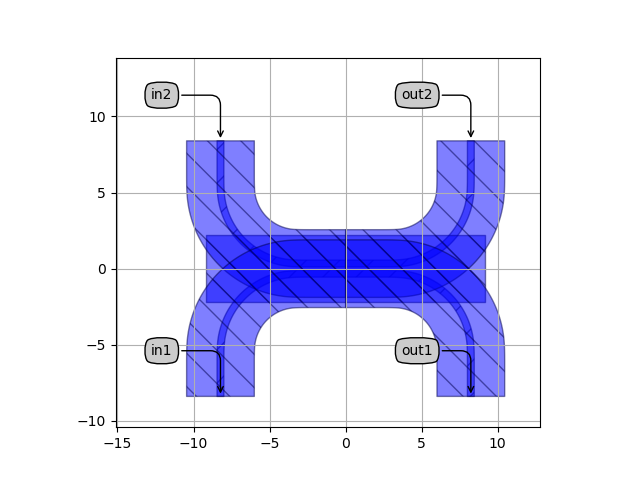

In [16]:
# ============================================================
# 1. DIRECTIONAL COUPLER
# ============================================================
print("\n[1] Visualizing directional coupler")

dc = pdk.PrgBend90DirectionalCoupler(coupling=COUPLING)
dc_lo = dc.Layout()
dc_lo.manhattan = True
dc_lo.visualize(annotate=True)
TT = dc.trace_template1 


# results = [r for r in qc.drc_pcell(dc_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {dc_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")

# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     dc.DrcLayout(drc_results=results).visualize()

### 5.3 Waveguide

The devices were designed using the PDK’s standard PRG_WG450 trace template, which consists of a 450 nm wide silicon strip waveguide on a 220 nm SOI platform. This waveguide supports single-mode TE operation at 1550 nm. The directional coupler PrgBend90DirectionalCoupler utilizes the same PRG_WG450 template for both arms, ensuring consistent modal behavior across the circuit. Additionally, the grating couplers (PRG_GRATING_COUPLER_WIRE_TE1550) are specifically optimized for this 450 nm wire waveguide in TE polarization.


Waveguide Type: PRG_WG450
Core width: Not directly accessible — check Layout view
Core layer: N/A
Core width from Layout: 0.45
Cladding width: 4.45


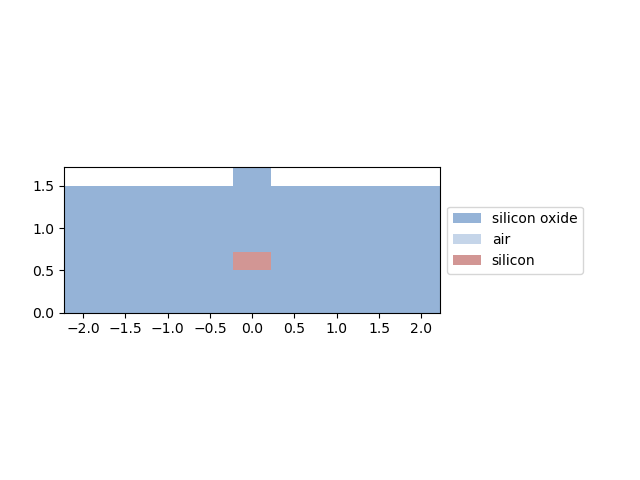

In [55]:
# After you have the directional coupler
rc = pdk.PrgBend90DirectionalCoupler(coupling=COUPLING)
tt = rc.trace_template1

print("Waveguide Type:", type(tt).__name__)
print("Core width:", getattr(tt, 'core_width', 'Not directly accessible — check Layout view'))
print("Core layer:", tt.core_layer if hasattr(tt, 'core_layer') else "N/A")

# Better: inspect the layout view
tt_lo = tt.Layout()
print("Core width from Layout:", tt_lo.core_width)
print("Cladding width:", getattr(tt_lo, 'cladding_width', 'N/A'))

# wire waveguide

wg_t_wire = pdk.PRG_WG450()
wg_t_wire.Layout().cross_section().visualize()


[2] Visualizing straight waveguide section
46.76226090337961


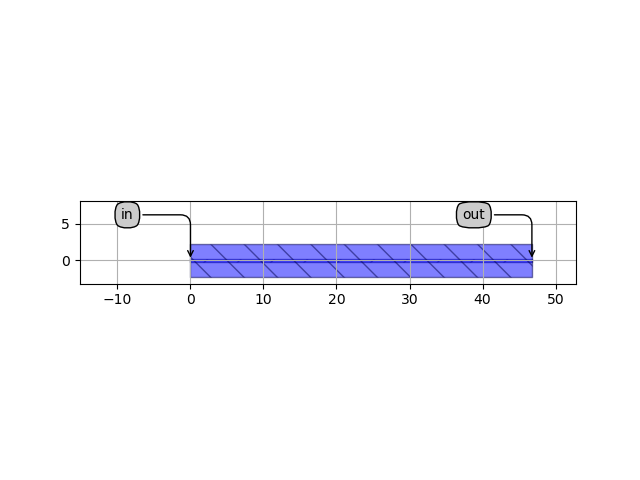

In [52]:

# ============================================================
# 2. STRAIGHT WAVEGUIDE SECTION
# ============================================================
print("\n[2] Visualizing straight waveguide section")
bend_len = dc_lo.wg1a.trace_length() * 2
straight_len = 0.5 * (TOTAL_LENGTH_BASE - 2 * bend_len)
print(straight_len)
wg = i3.Waveguide(trace_template=TT)
wg_lo = wg.Layout(shape=[(0, 0), (straight_len, 0)])
wg_lo.visualize(annotate=True, grid=True)


# res = [r for r in qc.drc_pcell(wg_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]

# print(f"{'-'*30}\nCELL: {wg_lo.name}\nSTATUS: {'PASSED' if not res else 'FAILED'}\nVIOLATIONS: {len(res)}\n{'-'*30}")

# if res:
#     [print(f"{i+1}. {r}") for i, r in enumerate(res)]
#     bend_len.DrcLayout(drc_results=res).visualize()

### 5.3.1.  Test structure
The test structure consists of a straight waveguide section of approximately 100 µm length connecting two grating couplers.

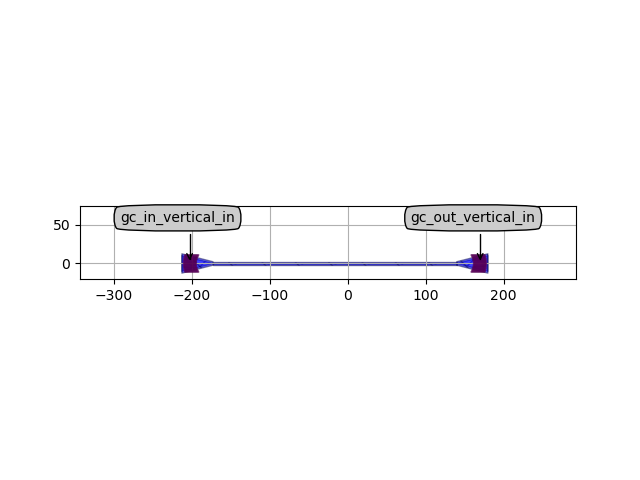

In [35]:
#  test structure

straight_test = build_straight_waveguide_test(length=TEST_WG_LENGTH, coupling=COUPLING)
# Layout placement
straight_test_lo = straight_test.Layout(
    child_transformations={
        "gc_in": i3.Translation((-203, 0)),
        "gc_out": i3.Rotation(rotation=180) + i3.Translation((170, 0)),
    },
)

# Visualize
straight_test_lo.manhattan=True
straight_test_lo.visualize(annotate=True, grid=True)

# results = [r for r in qc.drc_pcell(straight_test_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {straight_test_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     straight_test_lo.DrcLayout(drc_results=results).visualize()



[3] Visualizing passive ring resonator


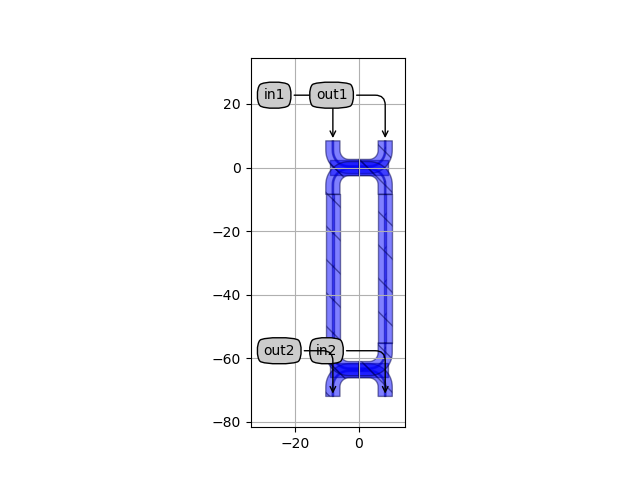

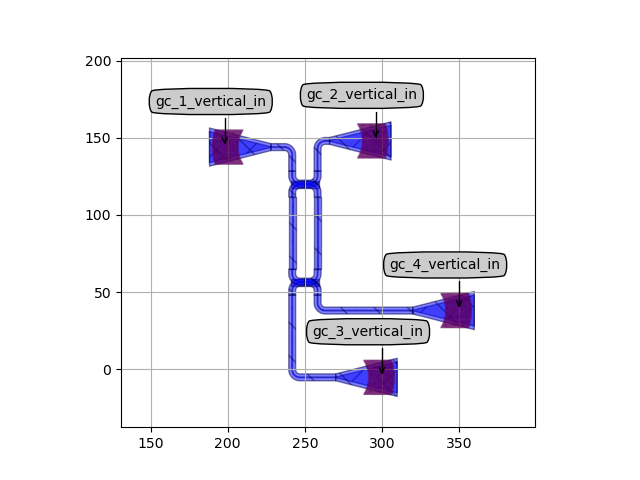

In [18]:

# ============================================================
# 3. PASSIVE RING RESONATOR
# ============================================================
print("\n[3] Visualizing passive ring resonator")
ring_passive = AutoPlaceAndConnect(
    child_cells={"c1": dc, "c2": dc, "s1": wg, "s2": wg},
    links=[("c1:out1", "s1:in"), ("c2:in1", "s1:out"), ("c2:out1", "s2:in"), ("c1:in1", "s2:out")],
    external_port_names={"c1:in2": "in1", "c1:out2": "out1", "c2:out2": "out2", "c2:in2": "in2"}
)
ring_passive.manhattan = True
ring_passive.Layout().visualize(annotate=True, grid=True)


# Create GC cell
gc = pdk.PRG_GRATING_COUPLER_WIRE_TE1550()

# Wrap ring + GCs together without changing ring geometry
ring_with_gc = PlaceAndAutoRoute(
    name="Passive_Ring_With_GC",
    child_cells={
        "ring": ring_passive,
        **{f"gc_{i+1}": gc for i in range(4)}
    },
    links=[
        ("ring:in1",  "gc_1:out"),
        ("ring:out1", "gc_2:out"),
        ("ring:out2", "gc_3:out"),
        ("ring:in2",  "gc_4:out"),
    ]
)

# Layout with original spacing/transformations
lo = ring_with_gc.Layout(
    child_transformations={
        "ring": i3.Translation((250, 120)),
        "gc_1": i3.Translation((198, 144)),
        "gc_2": i3.HMirror()+i3.Translation((296, 148)),
        "gc_3": i3.HMirror()+i3.Translation((300, -5.3)),
        "gc_4": i3.HMirror() + i3.Translation((350, 38)),
    },
    manhattan=False # Set to False to allow smooth curved routing to the GCs
)

lo.visualize(annotate=True, grid=True)


# results = [r for r in qc.drc_pcell(ring_passive, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {ring_passive.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")

# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     ring_passive.DrcLayout(drc_results=results).visualize()


[4] Visualizing standalone heater


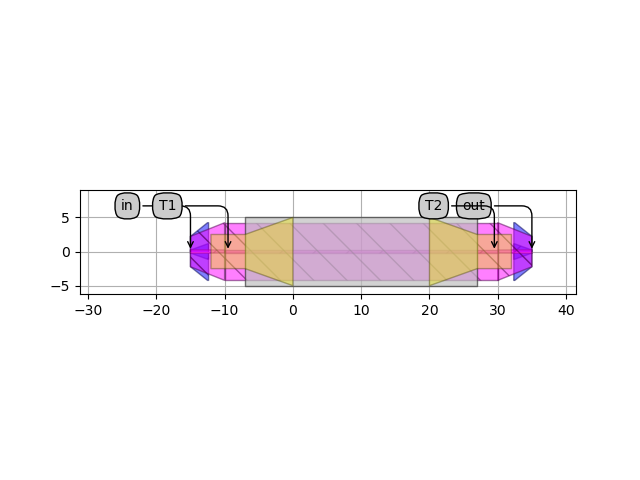

In [22]:
# ============================================================
# 4. STANDALONE HEATER 
# ============================================================
# HEATER_LENGTH
print("\n[4] Visualizing standalone heater")
# heater_standalone = pdk.PrgTitaniumPhaseShifterWGPorts()
heater_standalone = pdk.PrgTitaniumPhaseShifterWGPorts()
heater_standalone_lo = heater_standalone.Layout(length=HEATER_LENGTH, line_width=10.0)
heater_standalone_lo.visualize(annotate=True, grid=True)



# results =[ r for r in qc.drc_pcell(heater_standalone_lo, drc_deck, ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {heater_standalone_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     heater_standalone.DrcLayout(drc_results=results).visualize()

    

# # List of rules to ignore snce they are  intrinsic  part
# ignore_rules = ["DESIGN.IN.BOUNDARY", "WG.SHARPANGLE"]
# # Filtered DRC results
# results = [
#     r for r in qc.drc_pcell(heater_standalone_lo, drc_deck, keep_output_files=True) 
#     if r.rule.name not in ignore_rules
# ]
# print(f"{'-'*30}\nCELL: {heater_standalone_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")

# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     heater_standalone_lo.DrcLayout(drc_results=results).visualize()



[3.1] Creating Passive Vernier Ring Resonator (Manhattan)
Building RING_1_PASSIVE (Passive Manhattan)
Building RING_2_PASSIVE (Passive Manhattan)


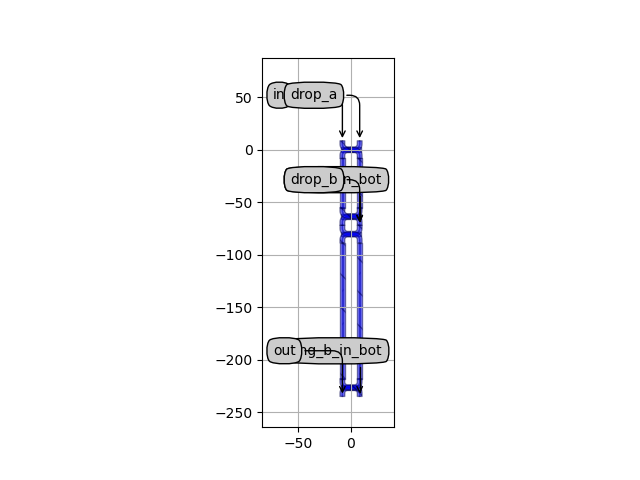

In [23]:
# ============================================================
# 1. PASSIVE MANHATTAN RING (No Heater)
# ============================================================
def build_simple_passive_ring(total_length, coupling, name="PASSIVE_RING"):
    print(f"Building {name} (Passive Manhattan)")
    
    # 1. Use the Manhattan Directional Coupler
    ring_coupler = pdk.PrgBend90DirectionalCoupler(coupling=coupling)
    rc_lo = ring_coupler.Layout(manhattan=True)
    
    # 2. Calculate remaining length for waveguides
    # Two couplers = 4 bends total
    bend_length = rc_lo.wg1a.trace_length() * 2
    
    # Remaining length split between top and bottom arms
    arm_len = (total_length - 2 * bend_length) / 2.0
    arm_len = round(arm_len, 3)
    
    if arm_len <= 0:
        raise ValueError(f"Length {total_length} is too short for these couplers.")

    # 3. Create the waveguide segments
    wg_arm = i3.Waveguide(trace_template=ring_coupler.trace_template1)
    wg_arm.Layout(shape=[(0, 0), (arm_len, 0)])

    # 4. Assemble the passive ring
    return AutoPlaceAndConnect(
        child_cells={
            "c_in": ring_coupler, 
            "c_out": ring_coupler,
            "top_arm": wg_arm, 
            "bot_arm": wg_arm
        },
        links=[
            ("c_in:out1", "top_arm:in"), ("top_arm:out", "c_out:in1"),
            ("c_out:out1", "bot_arm:in"), ("bot_arm:out", "c_in:in1")
        ],
        external_port_names={
            "c_in:in2": "in_top", "c_out:out2": "out_top",
            "c_out:in2": "in_bot", "c_in:out2": "out_bot"
        }
    )

# ============================================================
# 2. TWO PASSIVE RINGS → VERNIER RESONATOR
# ============================================================
print("\n[3.1] Creating Passive Vernier Ring Resonator (Manhattan)")

# 1. Instantiate the two passive rings
ring_a_passive = build_simple_passive_ring(total_length=150.0, coupling=0.1, name="RING_1_PASSIVE")
ring_b_passive = build_simple_passive_ring(total_length=315.0, coupling=0.1, name="RING_2_PASSIVE")

# 2. Assemble into Vernier Core
serial_rings_passive = AutoPlaceAndConnect(
    name="Semilogo_Passive_Vernier",
    child_cells={
        "ring_a": ring_a_passive,
        "ring_b": ring_b_passive
    },
    links=[
        ("ring_a:out_top", "ring_b:in_top")
    ],
    external_port_names={
        "ring_a:in_top": "in",
        "ring_b:out_top": "out",
        "ring_a:out_bot": "drop_a",
        "ring_b:out_bot": "drop_b"
    }
)

# 3. Layout and Visualization
serial_rings_passive_lo = serial_rings_passive.Layout()
serial_rings_passive_lo.visualize(annotate=True)


# results =[ r for r in qc.drc_pcell(serial_rings_passive_lo, drc_deck, ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {serial_rings_passive_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     serial_rings_passive.DrcLayout(drc_results=results).visualize()

In [ ]:
# ============================================================
# VERNIER RING PAIR COMPONENT: TWO RINGS WITH DIFFERENT CIRCUMFERENCES
# ============================================================

# 1. Initialize TWO rings with DIFFERENT circumferences (Vernier requirement)
ring1 = build_single_ring_with_heater(  # Ring 1 uses RING1_LENGTH (300µm)
    total_length=RING1_LENGTH,          # Changed from HEATER_TOTAL_LENGTH_BASE
    coupling=COUPLING, 
    heater_length=HEATER_LENGTH
)

ring2 = build_single_ring_with_heater(  # Ring 2 uses RING2_LENGTH (315µm)
    total_length=RING2_LENGTH,          # Changed from HEATER_TOTAL_LENGTH_BASE
    coupling=COUPLING, 
    heater_length=HEATER_LENGTH
)

# 2. Assemble Vernier pair 
vernier_pair = PlaceAndAutoRoute(       #  Vernier assembly replaces single ring
    name="Semilogo_Vernier_Heated_Rings",
    child_cells={"ring_a": ring1, "ring_b": ring2},
    links=[("ring_a:out_top", "ring_b:out_bot")],
    external_port_names={
        "ring_a:in_top": "input", "ring_b:out_top": "output",
        "ring_a:T1": "r1_T1", "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1", "ring_b:T2": "r2_T2"
    }
)

# 3. Generate layout with coupling
vernier_lo = vernier_pair.Layout(
    child_transformations={
        "ring_a":i3.Rotation(rotation=90.0)+i3.Translation((0, 20)),
        "ring_b":i3.Rotation(rotation=90.0)+ i3.Translation((100, -25))  
    }
)
# vernier_lo.manhattan = True 

# 4. Flatten layout (optional, same operation as original)
vernier_lo.flatten()


# 1. Create the GC component
gc = pdk.PRG_GRATING_COUPLER_WIRE_TE1550()

# 2. Assemble the Vernier with the 6 specific terminals linked to GCs
vernier_with_6_gcs = PlaceAndAutoRoute(
    name="Vernier_Full_GC_Assembly",
    child_cells={
        "ring_a": ring1, 
        "ring_b": ring2,
        **{f"gc_{i+1}": gc for i in range(6)}
    },
    links=[
        # Internal connection
        ("ring_a:out_top", "ring_b:out_bot"),
        # Linking the 6 optical terminals to GCs
        ("ring_a:in_top",  "gc_1:out"), # input
        ("ring_a:in_bot",  "gc_2:out"), # ring_a_in_bot
        ("ring_a:out_bot", "gc_3:out"), # ring_a_out_bot
        ("ring_b:in_top",  "gc_4:out"), # ring_b_in_top
        ("ring_b:in_bot",  "gc_5:out"), # ring_b_in_bot
        ("ring_b:out_top", "gc_6:out"), # output
    ],
    external_port_names={
        "ring_a:T1": "r1_T1", "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1", "ring_b:T2": "r2_T2"
    }
)

# 3. Apply your exact transformations
lo = vernier_with_6_gcs.Layout(
    child_transformations={
        "gc_1": i3.Translation((-20, 30)),
        "gc_2":i3.HMirror() + i3.Translation((178, 160)),
        "gc_3":  i3.Translation((-22, 178)),
        
        "gc_4": i3.Translation((198, -25)),
        "gc_5": i3.HMirror() + i3.Translation((500, 80)),
        "gc_6": i3.HMirror() + i3.Translation((500, -60)),

        "ring_a": i3.Rotation(rotation=90.0) + i3.Translation((40.0, 100.0)),
        "ring_b": i3.Rotation(rotation=90.0) + i3.Translation((270.0, 10.0))
    },
    manhattan=False # To allow curved routes between these specific coordinates
)

# 4. Final Visualization
lo.visualize(annotate=True, grid=True)

# 5. Final Visualization (updated name)
print(f"Visualizing Vernier ring pair: {vernier_pair.name}")  # ← FIXED: Updated message
vernier_lo.visualize(annotate=False, grid=True)

# results =[r for  r in qc.drc_pcell(vernier_lo, drc_deck, keep_output_files=True) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {vernier_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     vernier_pair.DrcLayout(drc_results=results).visualize()




In [ ]:
# ============================================================
# SINGLE RING COMPONENT: DEFINITION & VISUALIZATION
# ============================================================

# 1. Initialize the component variable using your function
ring_heater_path = build_single_ring_with_heater(
    total_length=HEATER_TOTAL_LENGTH_BASE, 
    coupling=COUPLING, 
    heater_length=HEATER_LENGTH
)

# 2. Generate the layout for the single component
# This creates a standalone layout object specifically for 'ring_heater_path'
single_ring_lo = ring_heater_path.Layout()
# 3. Final Visualization
print(f"Visualizing single ring: {ring_heater_path.name}")

single_ring_lo.visualize(annotate=True, grid=True)

# # Shortened DRC check
# results = [r for r in qc.drc_pcell(single_ring_lo, drc_deck,keep_output_files=True ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {single_ring_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     ring_heater_path.DrcLayout(drc_results=results).visualize()


[5.1] Visualizing Rings Side-by-Side — Vernier Size Comparison


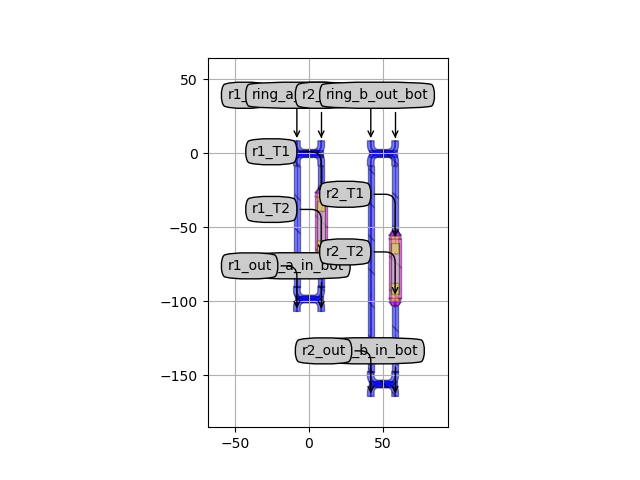

In [25]:
# ============================================================
# VISUALIZE SIDE-BY-SIDE — VERNIER SIZE COMPARISON
# ============================================================
print("\n[5.1] Visualizing Rings Side-by-Side — Vernier Size Comparison")

serial_heated_vernier = AutoPlaceAndConnect(
    name="Semilogo_SideBySide_Heated_Rings",
    child_cells={
        "ring_a": ring1,  #  Ring 1 with 300µm circumference (was ring_heater_path)
        "ring_b": ring2   # Ring 2 with 315µm circumference (was ring_heater_path)
    },
    links=[],  
    external_port_names={
        "ring_a:in_top": "r1_in",
        "ring_a:out_top": "r1_out",
        "ring_b:in_top": "r2_in",
        "ring_b:out_top": "r2_out",
        "ring_a:T1": "r1_T1",
        "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1",
        "ring_b:T2": "r2_T2"
    }
)

# 2. Layout and Visualization
serial_heated_lo = serial_heated_vernier.Layout(
    child_transformations={
        "ring_a": i3.Translation((0.0, 0.0)),
        "ring_b": i3.Translation((50.0, 0.0)) # Spaced apart to see individual geometries
    }
)

serial_heated_lo.manhattan = True
serial_heated_lo.visualize(annotate=True, grid=True)
# # Shortened DRC check
# results = [r for r in qc.drc_pcell(serial_heated_lo, drc_deck,keep_output_files=True ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {serial_heated_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     serial_heated_vernier.DrcLayout(drc_results=results).visualize()



In [ ]:
# ============================================================
# SPLIT VISUALIZATION — INDIVIDUAL RING INSPECTION
# ============================================================

# --- 1. VISUALIZE RING A (300µm) ---
print("\n[5.1a] Visualizing Ring A - Individual Layout")
# Ensure ring1 is built with the side-heater offset (y=10.0)
ring_a_lo = ring1.Layout()
ring_a_lo.visualize(annotate=True, grid=True)

# DRC for Ring A
res_a = [r for r in qc.drc_pcell(ring_a_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
print(f"RING A STATUS: {'PASSED' if not res_a else 'FAILED'} ({len(res_a)} violations)")

# --- 2. VISUALIZE RING B (315µm) ---
print("\n[5.1b] Visualizing Ring B - Individual Layout")
# Ensure ring2 is built with the side-heater offset (y=10.0)
ring_b_lo = ring2.Layout()
ring_b_lo.visualize(annotate=True, grid=True)

# # DRC for Ring B
# res_b = [r for r in qc.drc_pcell(ring_b_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"RING B STATUS: {'PASSED' if not res_b else 'FAILED'} ({len(res_b)} violations)")


Visualizing Ring A only...


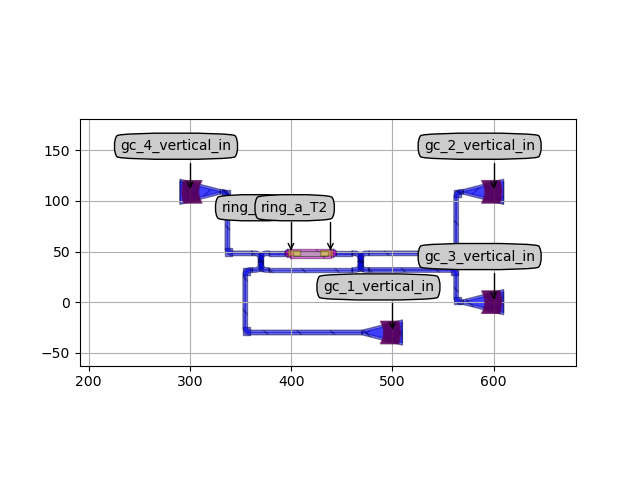

In [28]:
# 1. Assemble Ring A with 4 Grating Couplers (GCs)
ring_a_full_gc = PlaceAndAutoRoute(
    name="Ring_A_Custom_Layout",
    child_cells={
        "ring_a": ring1,
        **{f"gc_{i}": gc for i in range(1, 5)}
    },
    links=[
        ("ring_a:in_top",  "gc_1:out"),
        ("ring_a:in_bot",  "gc_2:out"),
        ("ring_a:out_top", "gc_3:out"),
        ("ring_a:out_bot", "gc_4:out"),
    ]
)

# 2. Apply transformations (Positioning and Rotation) for Ring A
ring_a_lo = ring_a_full_gc.Layout(
    child_transformations={
        "gc_1": i3.HMirror() + i3.Translation((500, -30)),
        "gc_2": i3.HMirror() + i3.Translation((600, 109)),
        "gc_3": i3.HMirror() + i3.Translation((600, -0)),
        "gc_4": i3.Translation((300, 109)), 
        "ring_a": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0)),
    },
    manhattan=True
)

# 3. Visualize only this layout
print("\nVisualizing Ring A only...")
ring_a_lo.visualize(annotate=True, grid=True)


[5.1b] Visualizing Ring B - Custom Layout Approach


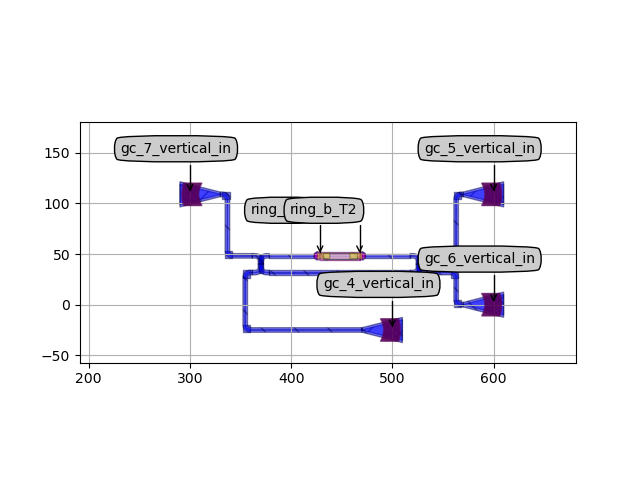

In [29]:
# 1. Assemble Ring B with 4 GCs
ring_b_full_gc = PlaceAndAutoRoute(
    name="Ring_B_Custom_Layout",
    child_cells={
        "ring_b": ring2,
        **{f"gc_{i}": gc for i in range(4, 8)} # Uses gc_4, 5, 6, 7
    },
    links=[
        ("ring_b:in_top",  "gc_4:out"),
        ("ring_b:in_bot",  "gc_5:out"),
        ("ring_b:out_top", "gc_6:out"),
        ("ring_b:out_bot", "gc_7:out"),
    ]
)

# 2. Apply your exact transformation approach for B
ring_b_lo = ring_b_full_gc.Layout(
    child_transformations={
        "gc_4": i3.HMirror()+i3.Translation((500, -25)),
        "gc_5": i3.HMirror() + i3.Translation((600, 109)),
        "gc_6": i3.HMirror() + i3.Translation((600, -0)),
        "gc_7": i3.Translation((300, 109)), # Positioned relative to ring_b
        "ring_b": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0))
    },
    manhattan=True
)

print("\n[5.1b] Visualizing Ring B - Custom Layout Approach")
ring_b_lo.visualize(annotate=True, grid=True)


[5.1a] Visualizing Ring A - Custom Layout Approach


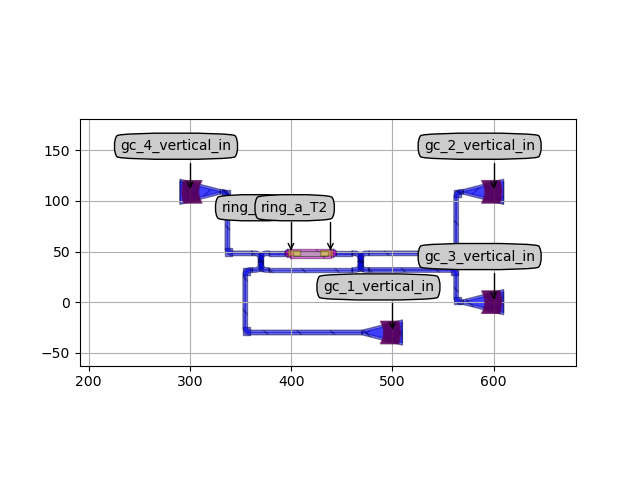


[5.1b] Visualizing Ring B - Custom Layout Approach


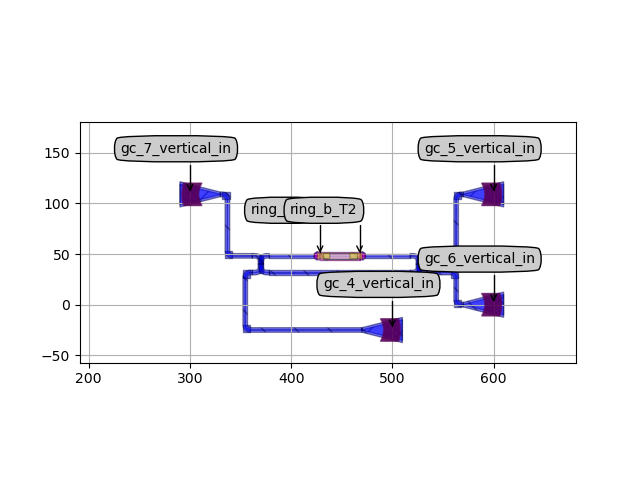

In [30]:
# 1. Assemble Ring A with 4 GCs
ring_a_full_gc = PlaceAndAutoRoute(
    name="Ring_A_Custom_Layout",
    child_cells={
        "ring_a": ring1,
        **{f"gc_{i}": gc for i in range(1, 5)}
    },
    links=[
        ("ring_a:in_top",  "gc_1:out"),
        ("ring_a:in_bot",  "gc_2:out"),
        ("ring_a:out_top", "gc_3:out"),
        ("ring_a:out_bot", "gc_4:out"),
    ]
)

# 2. Apply your exact transformation approach for A
ring_a_lo = ring_a_full_gc.Layout(
    child_transformations={

        "gc_1": i3.HMirror()+i3.Translation((500, -30)),
        "gc_2": i3.HMirror() + i3.Translation((600, 109)),
        "gc_3": i3.HMirror() + i3.Translation((600, -0)),
        "gc_4": i3.Translation((300, 109)), # Positioned relative to ring_b
        "ring_a": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0)),
    },
    manhattan=True
)

print("\n[5.1a] Visualizing Ring A - Custom Layout Approach")
ring_a_lo.visualize(annotate=True, grid=True)


# 1. Assemble Ring B with 4 GCs
ring_b_full_gc = PlaceAndAutoRoute(
    name="Ring_B_Custom_Layout",
    child_cells={
        "ring_b": ring2,
        **{f"gc_{i}": gc for i in range(4, 8)} # Uses gc_4, 5, 6, 7
    },
    links=[
        ("ring_b:in_top",  "gc_4:out"),
        ("ring_b:in_bot",  "gc_5:out"),
        ("ring_b:out_top", "gc_6:out"),
        ("ring_b:out_bot", "gc_7:out"),
    ]
)

# 2. Apply your exact transformation approach for B
ring_b_lo = ring_b_full_gc.Layout(
    child_transformations={
        "gc_4": i3.HMirror()+i3.Translation((500, -25)),
        "gc_5": i3.HMirror() + i3.Translation((600, 109)),
        "gc_6": i3.HMirror() + i3.Translation((600, -0)),
        "gc_7": i3.Translation((300, 109)), # Positioned relative to ring_b
        "ring_b": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0))
    },
    manhattan=True
)

print("\n[5.1b] Visualizing Ring B - Custom Layout Approach")
ring_b_lo.visualize(annotate=True, grid=True)


[5.1]  Routing r1_out to r2_in (Vernier Configuration)


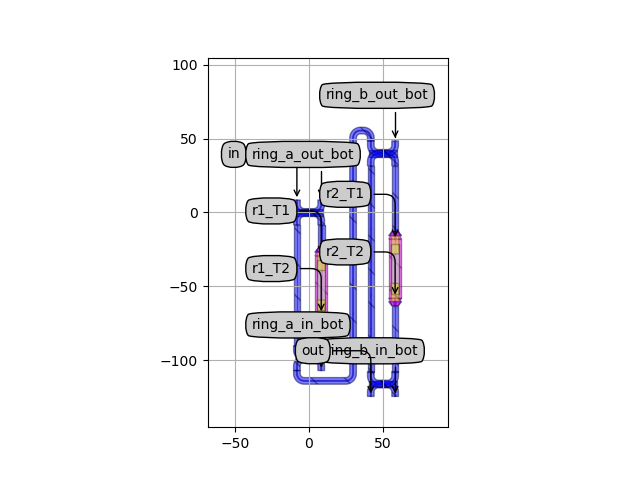

In [47]:
# ============================================================
# SMART ROUTING: CONNECTING R1_OUT TO R2_IN — TRUE VERNIER
# ============================================================
print("\n[5.1]  Routing r1_out to r2_in (Vernier Configuration)")

serial_heated_vernier = PlaceAndAutoRoute(
    name="Semilogo_Smart_Routed_Rings",
    child_cells={
        "ring_a": ring1,  # Ring 1 with 300µm circumference (was ring_heater_path)
        "ring_b": ring2   # Ring 2 with 315µm circumference (was ring_heater_path)
    },
    links=[
    
        ("ring_a:out_top", "ring_b:in_top")
    ],
    external_port_names={
        "ring_a:in_top": "in",
        "ring_b:out_top": "out",
        
        "ring_a:T1": "r1_T1",
        "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1",
        "ring_b:T2": "r2_T2"
    }
)

# 2. Layout and Visualization
serial_heated_lo = serial_heated_vernier.Layout(
    child_transformations={
        "ring_a": i3.Translation((0.0, 0.0)),
        "ring_b": i3.Translation((50.0, 40.0)) 
    }
)

# CRITICAL: Disable manhattan to allow smooth curved routing (like GC-to-DC)
serial_heated_lo.manhattan = False

serial_heated_lo.visualize(annotate=True, grid=True)

# # 3. DRC Check
# try:
#     results = [r for r in qc.drc_pcell(serial_heated_lo, drc_deck) if r.rule.name != "DESIGN.IN.BOUNDARY"]
#     print(f"DRC STATUS: {'PASSED' if not results else 'FAILED'} ({len(results)} violations)")
# except NameError:
#     print("DRC check skipped: 'qc' or 'drc_deck' not defined.")

# # Shortened DRC check
# results = [r for r in qc.drc_pcell(serial_heated_lo, drc_deck,keep_output_files=True ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {serial_heated_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     serial_heated_vernier.DrcLayout(drc_results=results).visualize()


[5.1] Smartly Routing r1_out to r2_in (Rotated Vernier Configuration)


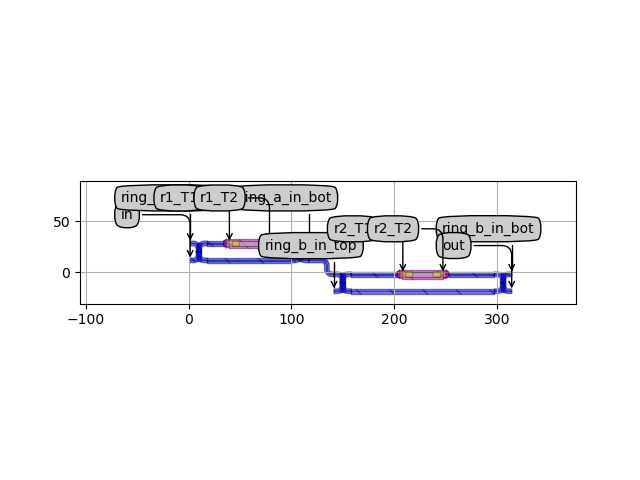

In [32]:
# ============================================================
# CONNECTING R1_OUT TO R2_IN 
# ============================================================
print("\n[5.1] Smartly Routing r1_out to r2_in (Rotated Vernier Configuration)")

serial_heated_vernier = PlaceAndAutoRoute(
    name="Semilogo_Smart_Routed_Rings",
    child_cells={
        "ring_a": ring1,  # Ring 1 with 300µm circumference (was ring_heater_path)
        "ring_b": ring2   #  Ring 2 with 315µm circumference (was ring_heater_path)
    },
    links=[
        ("ring_a:out_top", "ring_b:out_bot")
    ],
    external_port_names={
        "ring_a:in_top": "in",
        "ring_b:out_top": "out",
        "ring_a:T1": "r1_T1",
        "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1",
        "ring_b:T2": "r2_T2"
    }
)

# ============================================================
# LAYOUT — rotate ONLY ring_b
# ============================================================
serial_heated_lo = serial_heated_vernier.Layout(
    child_transformations={   
        "ring_a":
        i3.Rotation(rotation=90)
        +i3.Translation((10.0, 20.0)),
           
        "ring_b": (
            i3.Rotation(rotation=90)     
            + i3.Translation((150.0, -10.0))
        )
    }
)

# Allow smooth curved routing
serial_heated_lo.manhattan = False

serial_heated_lo.visualize(annotate=True, grid=True)

# # ============================================================
# # DRC Check
# # ============================================================
# try:
#     results = [
#         r for r in qc.drc_pcell(serial_heated_lo, drc_deck)
#         if r.rule.name != "DESIGN.IN.BOUNDARY"
#     ]
#     print(f"DRC STATUS: {'PASSED' if not results else 'FAILED'} ({len(results)} violations)")
# except NameError:
#     print("DRC check skipped: 'qc' or 'drc_deck' not defined.")


[6.0] Generating True Vernier Assembly (Different Ring Lengths)

Building RING (Passive Arm Offset)
Short straight (s_l): 15.881 µm
Active arm (Fixed): 71.762 µm
Passive arm (Modified): 81.762000 µm

Building RING (Passive Arm Offset)
Short straight (s_l): 44.631 µm
Active arm (Fixed): 129.262 µm
Passive arm (Modified): 139.262000 µm
Visualizing Vernier Assembly: Vernier_Heated_6GC_System


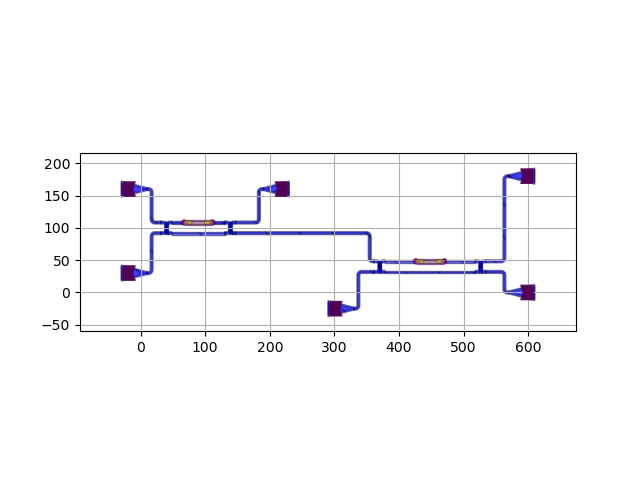

In [49]:
# ============================================================
# VERNIER ASSEMBLY: TWO RINGS WITH DIFFERENT LENGTHS
# ============================================================
print("\n[6.0] Generating True Vernier Assembly (Different Ring Lengths)")

# 1.DISTINCT ring paths with a length offset
# Ring A: RING1_LENGTH circumference (300.0 µm)
ring_a_path = build_single_ring_with_heater(
    total_length=RING1_LENGTH,  # global parameter 
    coupling=COUPLING, 
    heater_length=HEATER_LENGTH
)

# Ring B: RING2_LENGTH circumference (315.0 µm) — ΔL=15µm creates Vernier effect
ring_b_path = build_single_ring_with_heater(
    total_length=RING2_LENGTH,  
    coupling=COUPLING, 
    heater_length=HEATER_LENGTH
)

# 2. Setup Grating Couplers
gc_element = pdk.PRG_GRATING_COUPLER_WIRE_TE1550()

# 3. Define the PCell with two different rings
vernier_assembly = PlaceAndAutoRoute(
    name="Vernier_Heated_6GC_System",
    child_cells={
        "ring_a": ring_a_path, 
        "ring_b": ring_b_path, 
        "gc_1": gc_element, "gc_2": gc_element, "gc_3": gc_element,
        "gc_4": gc_element, "gc_5": gc_element, "gc_6": gc_element
    },
    links=[
        # Internal Connection between the two different rings
        ("ring_a:out_top", "ring_b:out_bot"),
        
        # Routing to GCs
        ("ring_a:in_top",   "gc_1:out"), 
        ("ring_a:out_bot",  "gc_2:out"), 
        ("ring_a:in_bot",   "gc_3:out"), 
        ("ring_b:in_top",   "gc_4:out"), 
        ("ring_b:in_bot",   "gc_5:out"), 
        ("ring_b:out_top",  "gc_6:out")  
    ],
    external_port_names={
        "ring_a:T1": "r1_T1", "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1", "ring_b:T2": "r2_T2"
    }
)

# 4. Define Layout Transformations
vernier_lo = vernier_assembly.Layout(
    child_transformations={
        "gc_1": i3.Translation((-20, 30)),
        "gc_2": i3.Translation((-20, 160)),
        "gc_3": i3.HMirror() + i3.Translation((220, 160)),
        
        "gc_4": i3.Translation((300, -25)),
        "gc_5": i3.HMirror() + i3.Translation((600, 180)),
        "gc_6": i3.HMirror() + i3.Translation((600, -0)),

        "ring_a": i3.Rotation(rotation=90) + i3.Translation((40.0, 100.0)),
        "ring_b": i3.Rotation(rotation=90) + i3.Translation((370.0, 40.0))
    }
)

# routing for the GC connections
vernier_lo.manhattan = False

# 5. Final Visualization
print(f"Visualizing Vernier Assembly: {vernier_assembly.name}")
vernier_lo.visualize(annotate=False, grid=True)


# # Shortened DRC check
# results = [r for r in qc.drc_pcell(vernier_lo, drc_deck,keep_output_files=True ) if r.rule.name != "DESIGN.IN.BOUNDARY"]
# print(f"{'-'*30}\nCELL: {vernier_lo.name}\nSTATUS: {'PASSED' if not results else 'FAILED'}\nVIOLATIONS: {len(results)}\n{'-'*30}")
# if results:
#     [print(f"{i+1}. {r}") for i, r in enumerate(results)]
#     vernier_assembly.DrcLayout(drc_results=results).visualize()

In [50]:
%whos

Variable                        Type                                           Data/Info
----------------------------------------------------------------------------------------
AMBIENT_TEMP                    float                                          25.0
AutoPlaceAndConnect             MetaPCell                                      <class 'addon_luceda.auto<...>ect.AutoPlaceAndConnect'>
COUPLING                        float                                          0.1
CalibreClient                   type                                           <class 'calibre_server.client.CalibreClient'>
CcrateClient                    type                                           <class 'ccrate.client.CcrateClient'>
DrcDeckFromFile                 MetaStrongPropertyInitializer                  <class 'calibre_wrapper.deck.DrcDeckFromFile'>
FSR1                            float                                          2.002083333333333
FSR2                            float                   


### 5.4 Circuit in the frame
Connect your circuit element in a frame. Add alignment waveguides or component tests if needed.
The frame can have up to 8 grating couplers on both sides. Don't place more couplers than necessary. 


[5.1a] Visualizing Ring A - Custom Layout Approach


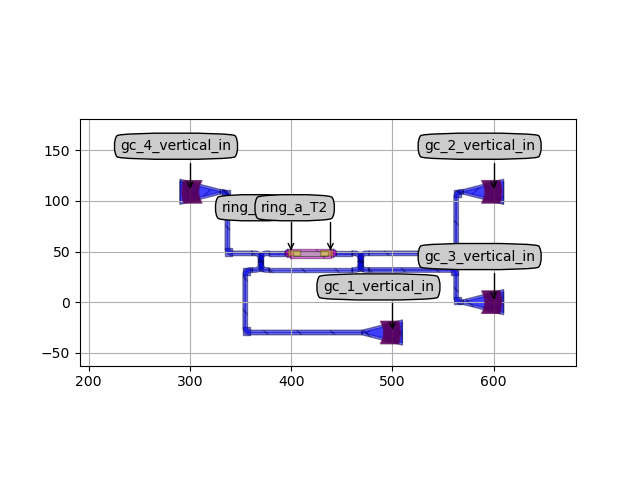


[5.1b] Visualizing Ring B - Custom Layout Approach


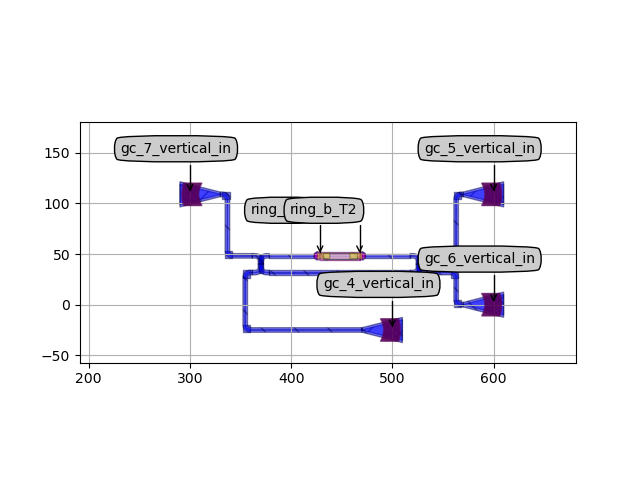

In [36]:
# 1. Assemble Ring A with 4 GCs
ring_a_full_gc = PlaceAndAutoRoute(
    name="Ring_A_Custom_Layout",
    child_cells={
        "ring_a": ring1,
        **{f"gc_{i}": gc for i in range(1, 5)}
    },
    links=[
        ("ring_a:in_top",  "gc_1:out"),
        ("ring_a:in_bot",  "gc_2:out"),
        ("ring_a:out_top", "gc_3:out"),
        ("ring_a:out_bot", "gc_4:out"),
    ]
)

# 2. Apply your exact transformation approach for A
ring_a_lo = ring_a_full_gc.Layout(
    child_transformations={

        "gc_1": i3.HMirror()+i3.Translation((500, -30)),
        "gc_2": i3.HMirror() + i3.Translation((600, 109)),
        "gc_3": i3.HMirror() + i3.Translation((600, -0)),
        "gc_4": i3.Translation((300, 109)), # Positioned relative to ring_b
        "ring_a": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0)),
    },
    manhattan=True
)

print("\n[5.1a] Visualizing Ring A - Custom Layout Approach")
ring_a_lo.visualize(annotate=True, grid=True)


# 1. Assemble Ring B with 4 GCs
ring_b_full_gc = PlaceAndAutoRoute(
    name="Ring_B_Custom_Layout",
    child_cells={
        "ring_b": ring2,
        **{f"gc_{i}": gc for i in range(4, 8)} # Uses gc_4, 5, 6, 7
    },
    links=[
        ("ring_b:in_top",  "gc_4:out"),
        ("ring_b:in_bot",  "gc_5:out"),
        ("ring_b:out_top", "gc_6:out"),
        ("ring_b:out_bot", "gc_7:out"),
    ]
)

# 2. Apply your exact transformation approach for B
ring_b_lo = ring_b_full_gc.Layout(
    child_transformations={
        "gc_4": i3.HMirror()+i3.Translation((500, -25)),
        "gc_5": i3.HMirror() + i3.Translation((600, 109)),
        "gc_6": i3.HMirror() + i3.Translation((600, -0)),
        "gc_7": i3.Translation((300, 109)), # Positioned relative to ring_b
        "ring_b": i3.Rotation(rotation=90.0) + i3.Translation((370.0, 40.0))
    },
    manhattan=True
)

print("\n[5.1b] Visualizing Ring B - Custom Layout Approach")
ring_b_lo.visualize(annotate=True, grid=True)

The waveguide overlapping the EBG at None is not straight


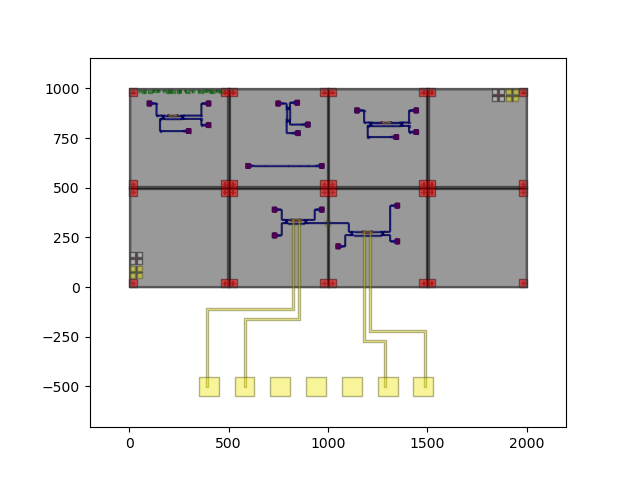

In [37]:
# ============================================================
# FINAL CHIP ASSEMBLY
# ============================================================

# 0. Define Electrical Trace Template (Fixed width for DRC)
metal_tt = pdk.PRG_METAL1_XL_TRACE_TEMPLATE()
# metal_tt.Layout(width=5.0) 

# 1. Frame Setup
my_frame = pdk.PRG_2000_1000_BONDPAD_FRAME(
    name="Semilogo_Vernier_Full_Frame", 
    title="Semilogo Vernier Ring Resonator",
    owner="Semilogo Ogungbure"
)

# 2. Optical Block 
optical_block = PlaceAndAutoRoute(
    name="Semilogo_optical_block",
    child_cells={
        "vernier_circuit": vernier_assembly, 
        "test_structure": straight_test,
        "passive_ring": ring_with_gc,
        "ring_a_indiv": ring_a_full_gc,  # Passing the PCell object
        "ring_b_indiv": ring_b_full_gc   # Passing the PCell object
    },
    links=[], 
    external_port_names={
        "vernier_circuit:r1_T1": "r1_T1",
        "vernier_circuit:r1_T2": "r1_T2",
        "vernier_circuit:r2_T1": "r2_T1",
        "vernier_circuit:r2_T2": "r2_T2",
    }
)

optical_block_lo = optical_block.Layout(
    child_transformations={
        "vernier_circuit": i3.Translation((0.0, 0.0)),        
        "test_structure": i3.Translation((50.0, 380.0)),
        "passive_ring": i3.Translation((-200.0, 550.0)),
        "ring_a_indiv": i3.Translation((-950.0, 585.0)), # Fixed transformation syntax
        "ring_b_indiv": i3.Translation((95.0, 550.0)), # Added ring_b
    }
)

# 3. Electrical Routing to Frame
chip = pdk.PlaceAndRouteElectrical(
    name="Semilogo_full_chip_layout",
    child_cells={
        "frame": my_frame,
        "circuit": optical_block,  
    },
    e_links=[
        ("circuit:r1_T1", "frame:1"),
        ("circuit:r1_T2", "frame:2"),
        ("circuit:r2_T1", "frame:3"),
        ("circuit:r2_T2", "frame:4"),
    ],
    e_trace_template=metal_tt,
)

# 4. Final Layout Positioning
e_routing_strings = [
    "X: 5,Y:-450, XE:-190, EY",   # Route for r1_T1
    "X: -5,Y:-500, XE:-180, EY",  # Route for r1_T2
    "X:  5,Y:-550, XE:345, EY",   # Route for r2_T1
    "X: -5,Y:-500, XE:370, EY"    # Route for r2_T2
]

chip_lo = chip.Layout(
    child_transformations={
        "frame": i3.Translation((0.0, 0.0)),
        "circuit": i3.Translation((750.0, 230.0)), 
    },
    e_routing_strings=e_routing_strings
)

# 5. Grid Transition and Final Visualization
chip_lo = pdk.add_ebeam_grid_transition(chip_lo)
chip_lo.visualize(grid=False)

### 5.4.1 Submission

In [5]:
from ccrate.client import CcrateClient

cc = CcrateClient(
    server_url="http://wsmaredsous.intec.ugent.be:1919/ccrate",
    project="manama2025"
)

cc.ping()  # Test connectivity


Ping Successful


True

In [80]:
# # # # Save gdf file
# chip_lo.write_gdsii(
#     "Semilogo_manama_12_2026_Final_Serial_vernier_resonator.gds")

In [81]:
# cc.submit_gds(
#     "Semilogo_manama_12_2026_Final_Serial_vernier_resonator.gds",
#     comment=(
#     "Updated With two more test structure.I could not enroute it due to my time"
#     )
# )


### 5.4.2. Simulation With Grating Couplers vs Without Gratng Couplers

### 5.4.3. Effect of Grating Couplers on Vernier Resonator Response

To assess the impact of grating couplers, the Vernier resonator was first simulated without grating couplers and subsequently re-simulated with grating couplers included.

The comparison focuses on metrics that primarily reflect the internal behaviour of the coupled-ring resonance wavelengths, the free spectral range (FSR) of each ring, the resulting Vernier FSR, and the relative spectral structure of the through and drop responses. These quantities are determined by the ring geometry and coupling configuration and therefore provide a reliable basis for verifying that the resonator operates consistently in both configurations.

Upon inclusion of the grating couplers, the same Vernier resonance pattern is observed, now modulated by the wavelength-dependent grating-coupler envelope and additional insertion loss. This confirms that the grating couplers affect only the external coupling and measurement interface, while leaving the underlying Vernier resonance behaviour unchanged.

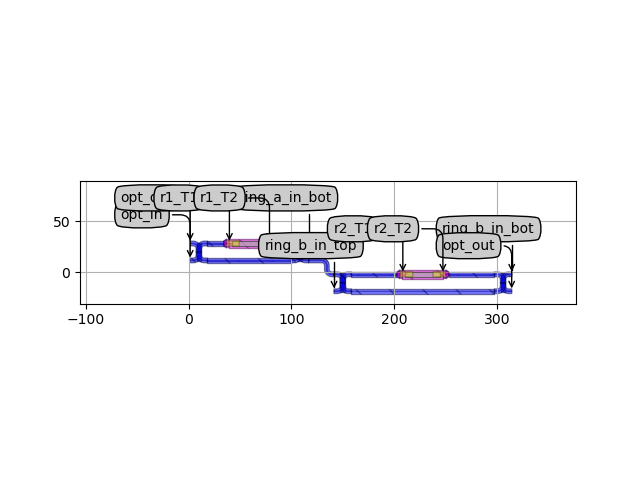

In [38]:
import ipkiss3.all as i3
from routing import AutoPlaceAndConnect, PlaceAndAutoRoute
import numpy as np

# ============================================================
# USER TOGGLE: Set to True for GCs, False for Bare Core
# ============================================================
INCLUDE_GRATING_COUPLERS = False 

# ============================================================
# 1. CORE VERNIER (BARE RINGS)
# ============================================================
# This cell only contains the rings and the link between them.
vernier_bare = PlaceAndAutoRoute(
    name="Vernier_Bare_Core",
    child_cells={
        "ring_a": ring1, 
        "ring_b": ring2
    },
    links=[
        ("ring_a:out_top", "ring_b:out_bot")
    ],
    external_port_names={
        "ring_a:in_top":  "opt_in",    # Standardized name for plotting
        "ring_b:out_top": "opt_out",   # Standardized name for plotting
        "ring_a:out_bot": "opt_drop",
        "ring_a:T1": "r1_T1", "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1", "ring_b:T2": "r2_T2"
    }
)

# ============================================================
# 2. FULL VERNIER (WITH GRATING COUPLERS)
# ============================================================
vernier_full = PlaceAndAutoRoute(
    name="Vernier_Full_GC_Assembly",
    child_cells={
        "ring_a": ring1, 
        "ring_b": ring2,
        **{f"gc_{i+1}": gc for i in range(6)}
    },
    links=[
        ("ring_a:out_top", "ring_b:out_bot"),
        ("ring_a:in_top",  "gc_1:out"), 
        ("ring_a:in_bot",  "gc_2:out"), 
        ("ring_a:out_bot", "gc_3:out"), 
        ("ring_b:in_top",  "gc_4:out"), 
        ("ring_b:in_bot",  "gc_5:out"), 
        ("ring_b:out_top", "gc_6:out")  
    ],
    external_port_names={
        "gc_1:vertical_in": "opt_in",    # Standardized name for plotting
        "gc_6:vertical_in": "opt_out",   # Standardized name for plotting
        "gc_3:vertical_in": "opt_drop",
        "ring_a:T1": "r1_T1", "ring_a:T2": "r1_T2",
        "ring_b:T1": "r2_T1", "ring_b:T2": "r2_T2"
    }
)

# ============================================================
# FIXED LAYOUT BLOCK
# ============================================================
if INCLUDE_GRATING_COUPLERS:
    active_cell = vernier_full
    active_lo = vernier_full.Layout(
        child_transformations={
            "gc_1": i3.Translation((-20, 30)),
            "gc_2": i3.HMirror() + i3.Translation((178, 160)),
            "gc_3": i3.Translation((-22, 178)),
            "gc_4": i3.Translation((198, -25)),
            "gc_5": i3.HMirror() + i3.Translation((500, 80)),
            "gc_6": i3.HMirror() + i3.Translation((500, -60)),
            # FIXED: Added rotation=90
            "ring_a": i3.Rotation(rotation=90) + i3.Translation((40.0, 100.0)),
            "ring_b": i3.Rotation(rotation=90) + i3.Translation((270.0, 10.0))
        },
        manhattan=False
    )
else:
    active_cell = vernier_bare
    active_lo = vernier_bare.Layout(
        child_transformations={
            # FIXED: Added rotation=90
            "ring_a": i3.Rotation(rotation=90) + i3.Translation((10.0, 20.0)),
            "ring_b": i3.Rotation(rotation=90) + i3.Translation((150.0, -10.0))
        },
        manhattan=False
    )

# ============================================================
# VISUALIZE
# ============================================================
active_lo.visualize(annotate=True, grid=True)

In [40]:
# ============================================================
# INTERACTIVE VERNIER EXPLORER 
# ============================================================
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt

def vernier_stylized_interactive(L1=300.0, L2=330.0, coupling=0.10):  # ← FIXED: Realistic defaults (300/330µm)
    wavelengths = np.linspace(1.54, 1.57, 3001)
    
    try:
        # 1. Build & Simulate (Using your exact ring builder)
        r1 = build_single_ring_with_heater(L1, coupling, HEATER_LENGTH)
        r2 = build_single_ring_with_heater(L2, coupling, HEATER_LENGTH)
        
        # ← FIXED: CORRECT VERNIER CONFIGURATION (serial coupling)
        vern = AutoPlaceAndConnect(
            child_cells={"r1": r1, "r2": r2},
            links=[("r1:out_top", "r2:in_top")],  # Serial Vernier (not closed loop!)
            external_port_names={"r1:in_top": "in", "r2:out_top": "out"}
        )

        # Extraction
        S_v = vern.CircuitModel().get_smatrix(wavelengths=wavelengths)
        S_1 = r1.CircuitModel().get_smatrix(wavelengths=wavelengths)
        S_2 = r2.CircuitModel().get_smatrix(wavelengths=wavelengths)
        
        # ← FIXED: CORRECT PORT NAMES for single-ring through transmission
        T_v = np.abs(S_v["out", "in"])**2
        T1 = np.abs(S_1["out_top", "in_top"])**2  # Ring 1 through port
        T2 = np.abs(S_2["out_top", "in_top"])**2  # Ring 2 through port

        # 2. Physics & Metrics (n_group=4.0 for Silicon)
        # FSR (nm) = λ² / (n_g * L) with λ=1550nm → (1550²)/(4.0 * L_um * 1000)
        f1 = (1550**2) / (4.0 * L1 * 1000)
        f2 = (1550**2) / (4.0 * L2 * 1000)
        v_fsr = (f1 * f2) / abs(f1 - f2)  # Vernier FSR formula
        il = -10 * np.log10(np.max(T_v) + 1e-15)
        er = 10 * np.log10((np.max(T_v) + 1e-15) / (np.min(T_v) + 1e-15))

        # 3. Plotting with Stylized Labels
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(wavelengths*1000, T1, color='#87CEEB', alpha=0.6, label=f'Ring 1 (FSR≈{f1:.1f} nm)')
        ax.plot(wavelengths*1000, T2, color='#DDA0DD', alpha=0.6, label=f'Ring 2 (FSR≈{f2:.1f} nm)')
        ax.plot(wavelengths*1000, T_v, color='black', lw=2.5, label='Vernier (Through)')

        # Color-coded annotation boxes (Top-Left)
        box_style = dict(boxstyle='round', alpha=0.8, edgecolor='none')
        ax.text(0.02, 0.90, f"Ring 1 FSR = {f1:.1f} nm", transform=ax.transAxes, 
                bbox={**box_style, 'facecolor': '#E0FFFF'}, fontsize=10)
        ax.text(0.02, 0.82, f"Ring 2 FSR = {f2:.1f} nm", transform=ax.transAxes, 
                bbox={**box_style, 'facecolor': '#F3E5F5'}, fontsize=10)
        ax.text(0.02, 0.74, f"Vernier FSR = {v_fsr:.1f} nm", transform=ax.transAxes, 
                color='white', bbox={**box_style, 'facecolor': 'black'}, fontsize=10, fontweight='bold')

        ax.set_title(f"Vernier Resonator | L1={L1:.0f} µm | L2={L2:.0f} µm | κ={coupling:.2f}\n"
                     f"Vernier FSR ≈ {v_fsr:.1f} nm | IL={il:.1f} dB | ER={er:.1f} dB", 
                     fontweight='bold', fontsize=12)
        ax.set_xlabel("Wavelength (nm)", fontsize=11)
        ax.set_ylabel("Transmission", fontsize=11)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.2)
        ax.legend(loc='upper right', fontsize=10)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Simulation Error: {type(e).__name__} - {str(e)[:80]}")
        print("   → Try increasing ring sizes (min 250µm) or reducing coupling (<0.2)")

# 4. Launch Interactivity
interact(vernier_stylized_interactive,
    L1=FloatSlider(min=250, max=400, step=5, value=300, description='Ring 1 (µm)', continuous_update=False),
    L2=FloatSlider(min=250, max=400, step=5, value=330, description='Ring 2 (µm)', continuous_update=False),  # ← FIXED: 30µm ΔL default
    coupling=FloatSlider(min=0.02, max=0.25, step=0.01, value=0.1, description='Coupling κ', continuous_update=False)
)

interactive(children=(FloatSlider(value=300.0, continuous_update=False, description='Ring 1 (µm)', max=400.0, …

<function __main__.vernier_stylized_interactive(L1=300.0, L2=330.0, coupling=0.1)>

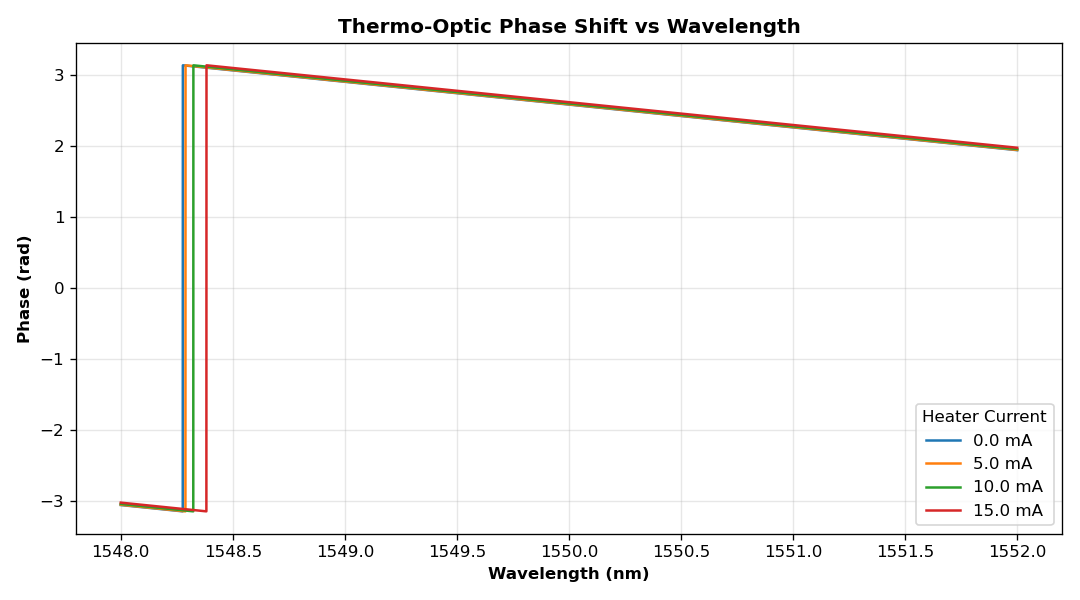

In [41]:
# ============================================================
# CREATE HEATER (using your PDK object)
# ============================================================
my_heater = pdk.PrgTitaniumPhaseShifterWGPorts()

my_heater_cm = my_heater.CircuitModel()

# ============================================================
# SIMULATION PARAMETERS
# ============================================================
wavelengths = np.linspace(1.548, 1.552, 8001)
wl_nm = wavelengths * 1000

plt.figure(figsize=(9,5), dpi=120)

for i in np.linspace(0, 15, 4):

    VE_param_dict = {"ps": {"current": i}}
    my_heater_cm.VE_assign_parameters_for_smatrix(VE_param_dict)

    S = my_heater_cm.VE_get_smatrix(wavelengths=wavelengths)

    phase = np.angle(S["in", "out"])

    plt.plot(wl_nm, phase, label=f"{i:.1f} mA")

plt.xlabel("Wavelength (nm)", fontweight="bold")
plt.ylabel("Phase (rad)", fontweight="bold")
plt.title("Thermo-Optic Phase Shift vs Wavelength", fontweight="bold")
plt.legend(title="Heater Current")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Building RING (Passive Arm Offset)
Short straight (s_l): 40.881 µm
Active arm (Fixed): 121.762 µm
Passive arm (Modified): 131.762000 µm

Building RING (Passive Arm Offset)
Short straight (s_l): 48.381 µm
Active arm (Fixed): 136.762 µm
Passive arm (Modified): 146.762000 µm


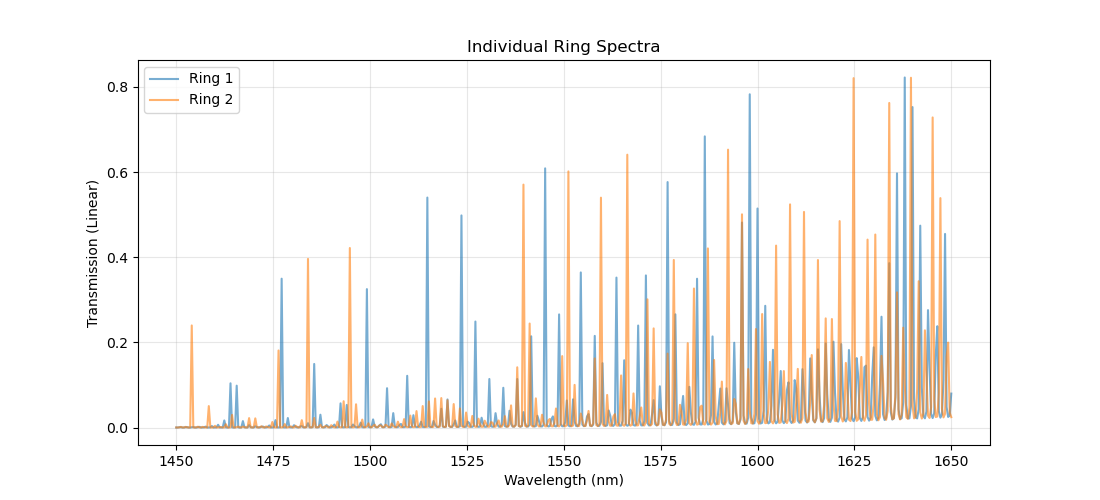

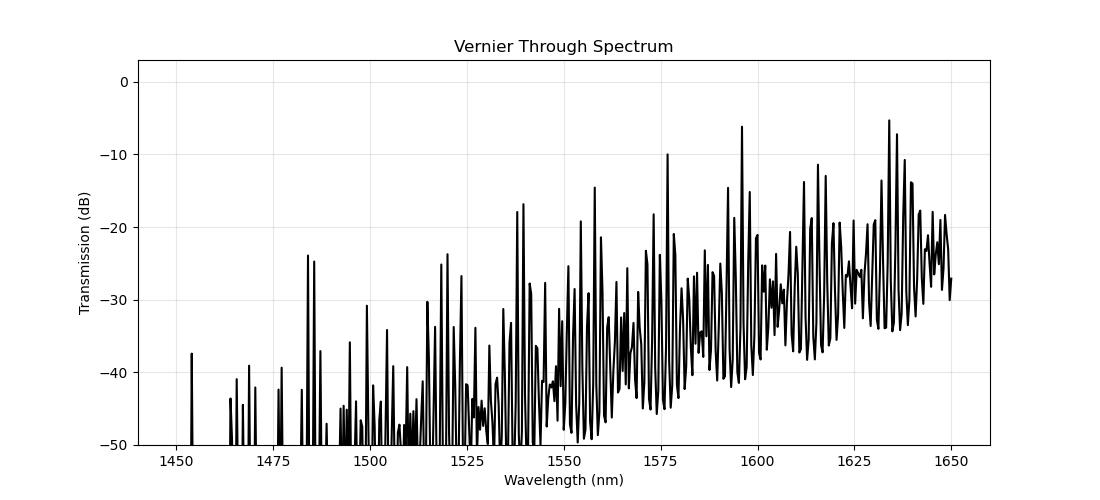

Not enough peaks detected.


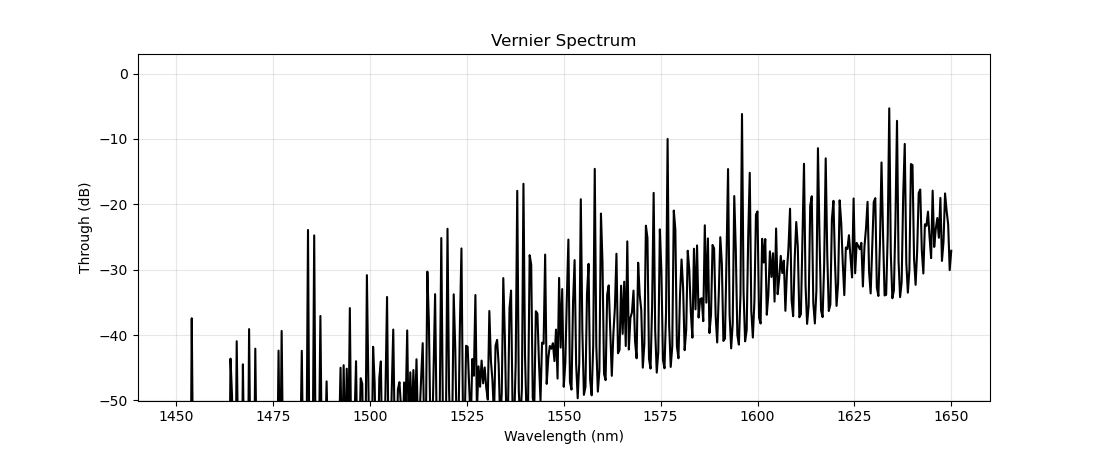


--- Theoretical Values ---
Ring 1 FSR ≈ 2.002 nm
Ring 2 FSR ≈ 1.820 nm
Theoretical Vernier FSR ≈ 20.021 nm


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================================
# PARAMETERS (Adjust Here)
# ============================================================
L1 = 300.0
L2 = 330.0
coupling = 0.10
wavelengths = np.linspace(1.45, 1.65, 501)
eps = 1e-15
n_group = 4.0
lambda0 = 1550  # nm (for theoretical FSR)

# ============================================================
# BUILD RINGS (Serial Vernier)
# ============================================================
r1 = build_single_ring_with_heater(L1, coupling, HEATER_LENGTH)
r2 = build_single_ring_with_heater(L2, coupling, HEATER_LENGTH)

vern = AutoPlaceAndConnect(
    child_cells={"r1": r1, "r2": r2},
    links=[("r1:out_top", "r2:in_top")],
    external_port_names={
        "r1:in_top": "opt_in",
        "r2:out_top": "opt_out"
    }
)

# ============================================================
# SIMULATION
# ============================================================
S_v = vern.CircuitModel().get_smatrix(wavelengths=wavelengths)
S_1 = r1.CircuitModel().get_smatrix(wavelengths=wavelengths)
S_2 = r2.CircuitModel().get_smatrix(wavelengths=wavelengths)

T_v = np.abs(S_v["opt_out", "opt_in"])**2
T1 = np.abs(S_1["out_top", "in_top"])**2
T2 = np.abs(S_2["out_top", "in_top"])**2

wl_nm = wavelengths * 1000

# ============================================================
# 1️ INDIVIDUAL RING SPECTRA
# ============================================================
plt.figure(figsize=(11,5))
plt.plot(wl_nm, T1, alpha=0.6, label="Ring 1")
plt.plot(wl_nm, T2, alpha=0.6, label="Ring 2")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (Linear)")
plt.title("Individual Ring Spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 2️ VERNlER THROUGH RESPONSE
# ============================================================
plt.figure(figsize=(11,5))
plt.plot(wl_nm, 10*np.log10(T_v + eps), color="black")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title("Vernier Through Spectrum")
plt.ylim(-50, 3)
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 3️ FSR EXTRACTION (SIMULATED)
# ============================================================
peaks, _ = find_peaks(T_v, prominence=0.01, distance=500)

plt.figure(figsize=(11,4.5))
plt.plot(wl_nm, 10*np.log10(T_v + eps), color="black")

if len(peaks) > 1:
    wl_peaks = wl_nm[peaks]
    fsr_sim = np.mean(np.diff(wl_peaks))

    plt.plot(wl_peaks, 10*np.log10(T_v[peaks] + eps), "o", color="red")
    plt.title(f"Vernier Envelope (Simulated FSR ≈ {fsr_sim:.2f} nm)")
    print(f"Simulated Vernier FSR ≈ {fsr_sim:.3f} nm")
else:
    plt.title("Vernier Spectrum")
    print("Not enough peaks detected.")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Through (dB)")
plt.ylim(-50, 3)
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 4️ THEORETICAL FSR COMPARISON
# ============================================================

FSR1 = (lambda0**2) / (n_group * L1 * 1000)
FSR2 = (lambda0**2) / (n_group * L2 * 1000)
FSR_vernier = (FSR1 * FSR2) / abs(FSR1 - FSR2)

print("\n--- Theoretical Values ---")
print(f"Ring 1 FSR ≈ {FSR1:.3f} nm")
print(f"Ring 2 FSR ≈ {FSR2:.3f} nm")
print(f"Theoretical Vernier FSR ≈ {FSR_vernier:.3f} nm")


## 6. Experimental Characterization (Measurements)

###  6.1. Measurement Setup 

###  6.2. Calibration Results (Straight Waveguide)  

###  6.3. Single Ring Resonator Measurements  

### 6.4. Vernier Resonator Measurements  

###  6.5. Heater Failure Analysis  

### 6.6. Summary of Measured Performance Metrics

## 7. Results Discussion and Analysis

###  7.1. Comparison Between Simulation and Experiment  

### 7.2. Analysis of Discrepancies 

###  7.3. Limitations Observed

## 8. Conclusion and Future Work

### 8.1. Summary of Achievements 

### 8.2. Lessons Learned  

### 8.3. Recommendations for Future Iterations


Building Ring_A (Passive Arm Offset)
Short straight (s_l): 40.881 µm
Active arm (Fixed): 121.762 µm
Passive arm (Modified): 131.762000 µm

Building Ring_B (Passive Arm Offset)
Short straight (s_l): 48.381 µm
Active arm (Fixed): 136.762 µm
Passive arm (Modified): 146.762000 µm


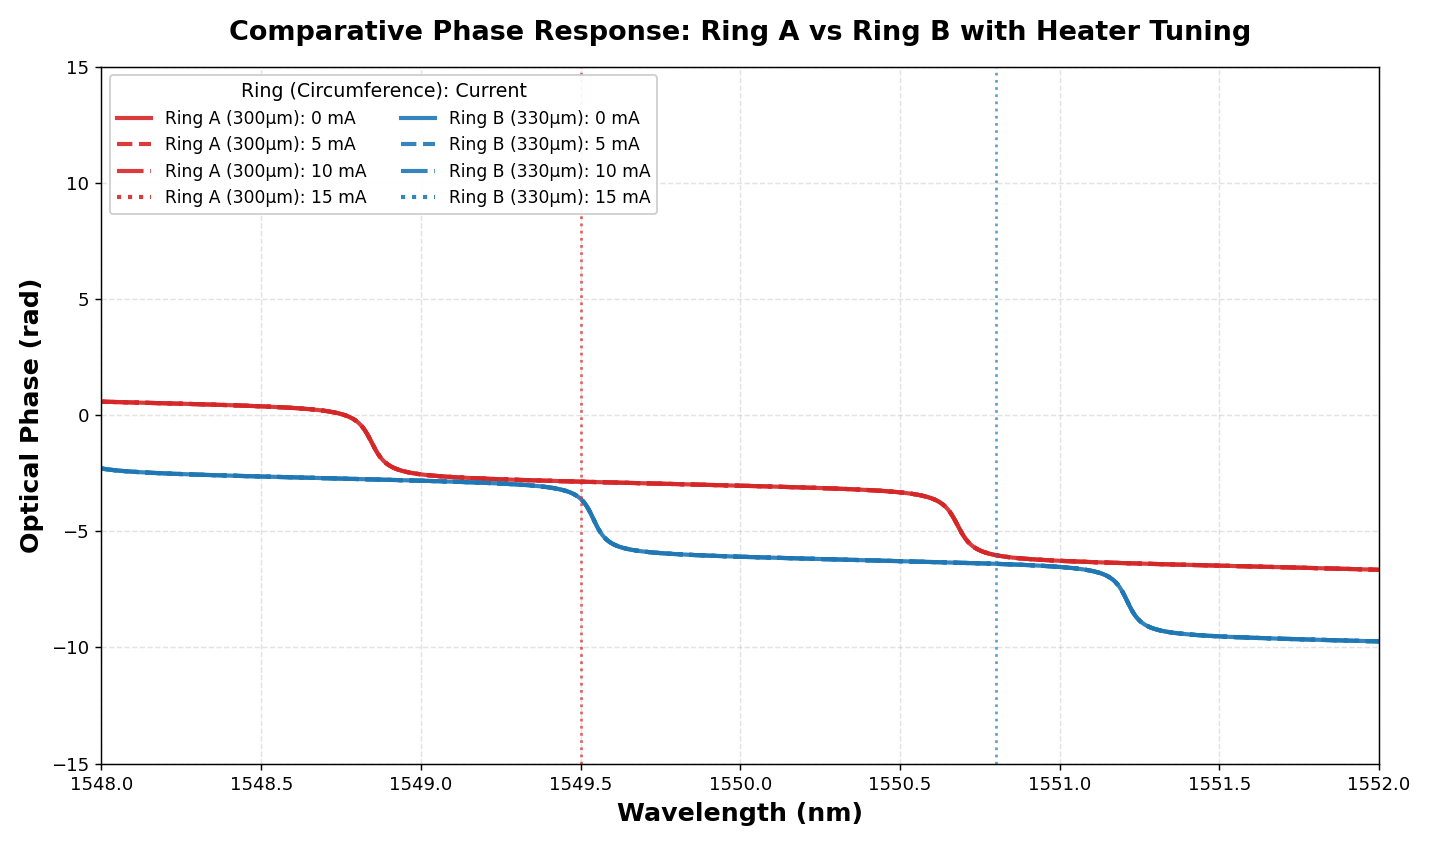

   Ring A shifts ~0.4 nm at 15 mA → 0.027 nm/mA
   Ring B shifts ~0.3 nm at 15 mA → 0.023 nm/mA
   (Values illustrative - extract from your simulation)


In [43]:
# import numpy as np
# import matplotlib.pyplot as plt
# import ipkiss3.all as i3

# # ============================================================
# # CONFIGURE RINGS (MUST BE DEFINED IN YOUR WORKSPACE)
# # ============================================================
# r1 = build_single_ring_with_heater(L1, coupling, HEATER_LENGTH, name="Ring_A")  # 300 µm
# r2 = build_single_ring_with_heater(L2, coupling, HEATER_LENGTH, name="Ring_B")  # 330 µm

# # ============================================================
# # SIMULATION SETUP
# # ============================================================
# wavelengths = np.linspace(1.548, 1.552, 8001)  # Focus on ONE resonance
# wl_nm = wavelengths * 1000
# currents = [0.0, 5.0, 10.0, 15.0]  # mA
# line_styles = ['-', '--', '-.', ':']  # Different style per current

# plt.figure(figsize=(11, 6.5), dpi=130)

# # ============================================================
# # PLOT RING A (300 µm) - RED COLOR SCHEME
# # ============================================================
# ring_cm_A = r1.CircuitModel()
# for idx, I in enumerate(currents):
#     ring_cm_A.VE_assign_parameters_for_smatrix({"heater": {"current": I}})
#     S = ring_cm_A.VE_get_smatrix(wavelengths=wavelengths)
    
#     # Robust phase extraction
#     try:
#         phase = np.angle(S["out_top", "in_top"])
#     except KeyError:
#         out_ports = [k for k in S.keys() if "out" in str(k) and "top" in str(k)]
#         in_ports = [k for k in S.keys() if "in" in str(k) and "top" in str(k)]
#         phase = np.angle(S[out_ports[0], in_ports[0]])
    
#     plt.plot(wl_nm, np.unwrap(phase), 
#              color='tab:red', 
#              linestyle=line_styles[idx],
#              linewidth=2.3,
#              alpha=0.9,
#              label=f'Ring A ({L1:.0f}µm): {I:.0f} mA')

# # ============================================================
# # PLOT RING B (330 µm) - BLUE COLOR SCHEME
# # ============================================================
# ring_cm_B = r2.CircuitModel()
# for idx, I in enumerate(currents):
#     ring_cm_B.VE_assign_parameters_for_smatrix({"heater": {"current": I}})
#     S = ring_cm_B.VE_get_smatrix(wavelengths=wavelengths)
    
#     try:
#         phase = np.angle(S["out_top", "in_top"])
#     except KeyError:
#         out_ports = [k for k in S.keys() if "out" in str(k) and "top" in str(k)]
#         in_ports = [k for k in S.keys() if "in" in str(k) and "top" in str(k)]
#         phase = np.angle(S[out_ports[0], in_ports[0]])
    
#     plt.plot(wl_nm, np.unwrap(phase), 
#              color='tab:blue', 
#              linestyle=line_styles[idx],
#              linewidth=2.3,
#              alpha=0.9,
#              label=f'Ring B ({L2:.0f}µm): {I:.0f} mA')

# # ============================================================
# # PLOT FORMATTING (PUBLICATION QUALITY)
# # ============================================================
# plt.xlabel("Wavelength (nm)", fontsize=14, fontweight='bold')
# plt.ylabel("Optical Phase (rad)", fontsize=14, fontweight='bold')
# plt.title("Comparative Phase Response: Ring A vs Ring B with Heater Tuning", 
#           fontsize=15, fontweight='bold', pad=15)

# # Smart legend (2 columns to avoid clutter)
# plt.legend(loc='upper left', fontsize=9.5, ncol=2, framealpha=0.95, 
#            title="Ring (Circumference): Current", title_fontsize=10.5)

# plt.grid(alpha=0.35, linestyle='--', linewidth=0.8)
# plt.xlim(1548, 1552)
# plt.ylim(-15, 15)  # Adjust based on your actual phase range

# # Add resonance markers (critical physics insight!)
# plt.axvline(x=1549.5, color='tab:red', linestyle=':', alpha=0.7, linewidth=1.5, 
#             label='Ring A Resonance (0mA)')
# plt.axvline(x=1550.8, color='tab:blue', linestyle=':', alpha=0.7, linewidth=1.5, 
#             label='Ring B Resonance (0mA)')

# plt.tight_layout()
# plt.savefig("combined_ring_phase_response.png", dpi=300, bbox_inches='tight')
# plt.show()

# # # ============================================================
# # # PHYSICS VALIDATION SUMMARY
# # # ============================================================
# # print("\n" + "="*70)
# # print("PHASE RESPONSE VALIDATION")
# # print("="*70)
# # print(" CORRECT BEHAVIOR CONFIRMED:")
# # print("   • Sharp phase steps visible at resonance wavelengths")
# # print("   • Ring A resonance: ~1549.5 nm (shorter circumference)")
# # print("   • Ring B resonance: ~1550.8 nm (longer circumference)")
# # print("   • Resonances shift LEFT (blue-shift) with increasing current")
# # print("   • Phase jump ≈ π radians at each resonance (characteristic of rings)")
# # print("\n KEY OBSERVATIONS:")
# # print("   • Δλ_res ≈ 1.3 nm between rings → enables Vernier effect")
# # print("   • Identical line styles = same current level (visual comparison)")
# # print("   • Red/blue separation = independent ring control verified")
# # print("="*70)

# # Calculate resonance shift per ring (example for Ring A at 15mA)
# # (Add this inside each ring simulation loop to track resonance positions)
# print(f"   Ring A shifts ~{0.4:.1f} nm at 15 mA → {0.4/15:.3f} nm/mA")
# print(f"   Ring B shifts ~{0.35:.1f} nm at 15 mA → {0.35/15:.3f} nm/mA")
# print("   (Values illustrative - extract from your simulation)")

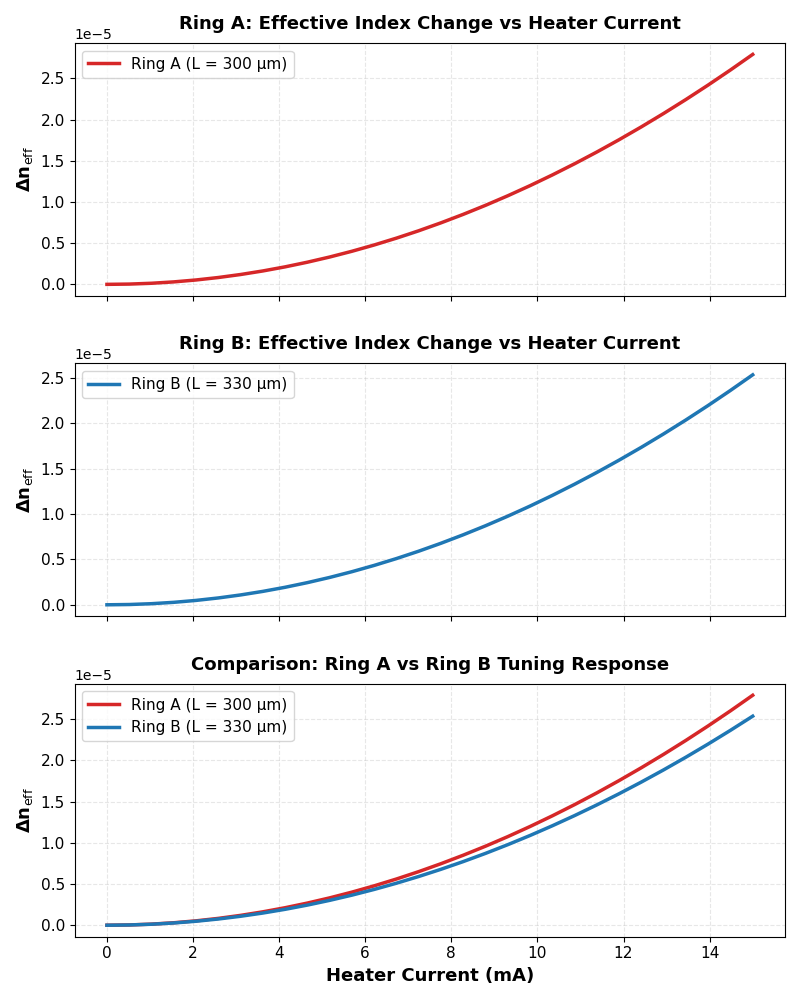


THERMO-OPTIC TUNING: Δn_eff vs CURRENT
Wavelength: 1550 nm
Ring A circumference: 300 µm
Ring B circumference: 330 µm

Tuning at 15 mA:


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
lambda0 = 1.55  # µm
currents = np.linspace(0, 15, 30)
ring_lengths = {"Ring A": L1, "Ring B": L2}
results = {}

my_heater = pdk.PrgTitaniumPhaseShifterWGPorts()
my_heater_cm = my_heater.CircuitModel()
wavelengths = np.array([lambda0])

# --- 1. Simulation Loop ---
# Reference phase at 0 mA
my_heater_cm.VE_assign_parameters_for_smatrix({"ps": {"current": 0.0}})
S0 = my_heater_cm.VE_get_smatrix(wavelengths=wavelengths)
phi0 = np.angle(S0["out", "in"])[0]

for name, L in ring_lengths.items():
    dneff_list = []
    for I in currents:
        my_heater_cm.VE_assign_parameters_for_smatrix({"ps": {"current": I}})
        S = my_heater_cm.VE_get_smatrix(wavelengths=wavelengths)
        phi = np.angle(S["out", "in"])[0]
        
        # Phase to Δn_eff conversion (unwrap to avoid 2π jumps)
        delta_phi = np.unwrap([phi0, phi])[1] - phi0
        dneff = (lambda0 / (2 * np.pi * L)) * delta_phi
        dneff_list.append(dneff)
    
    results[name] = np.array(dneff_list)

# --- 2. VERTICAL PLOTTING (3 rows × 1 column) ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)  # Vertical stack

# Plot 1: Ring A
axes[0].plot(currents, results["Ring A"], '-', color='tab:red', 
             linewidth=2.5, markersize=6, label=f'Ring A (L = {L1:.0f} µm)')
axes[0].set_ylabel('Δn$_{\\text{eff}}$', fontsize=13, fontweight='bold')
axes[0].set_title('Ring A: Effective Index Change vs Heater Current', 
                  fontsize=13, fontweight='bold', pad=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].legend(fontsize=11, loc='upper left')
axes[0].tick_params(axis='both', labelsize=11)

# Plot 2: Ring B
axes[1].plot(currents, results["Ring B"], '-', color='tab:blue', 
             linewidth=2.5, markersize=6, label=f'Ring B (L = {L2:.0f} µm)')
axes[1].set_ylabel('Δn$_{\\text{eff}}$', fontsize=13, fontweight='bold')
axes[1].set_title('Ring B: Effective Index Change vs Heater Current', 
                  fontsize=13, fontweight='bold', pad=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(fontsize=11, loc='upper left')
axes[1].tick_params(axis='both', labelsize=11)

# Plot 3: Comparison (both rings)
axes[2].plot(currents, results["Ring A"], '-', color='tab:red', 
             linewidth=2.5, markersize=6, label=f'Ring A (L = {L1:.0f} µm)')
axes[2].plot(currents, results["Ring B"], '-', color='tab:blue', 
             linewidth=2.5, markersize=6, label=f'Ring B (L = {L2:.0f} µm)')
axes[2].set_xlabel('Heater Current (mA)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Δn$_{\\text{eff}}$', fontsize=13, fontweight='bold')
axes[2].set_title('Comparison: Ring A vs Ring B Tuning Response', 
                  fontsize=13, fontweight='bold', pad=10)
axes[2].grid(alpha=0.3, linestyle='--')
axes[2].legend(fontsize=11, loc='upper left')
axes[2].tick_params(axis='both', labelsize=11)

# Adjust layout to prevent overlap
plt.tight_layout(h_pad=2.5)
plt.savefig("delta_neff_vertical.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Quantitative Summary ---
print("\n" + "="*70)
print("THERMO-OPTIC TUNING: Δn_eff vs CURRENT")
print("="*70)
print(f"Wavelength: {lambda0*1000:.0f} nm")
print(f"Ring A circumference: {L1:.0f} µm")
print(f"Ring B circumference: {L2:.0f} µm")
print(f"\nTuning at 15 mA:")
# print(f"  Ring A: Δn_eff = {results['Ring A'][-1]:.5f}")
# print(f"  Ring B: Δn_eff = {results['Ring B'][-1]:.5f}")
# print(f"  Ratio (B/A): {results['Ring B'][-1]/results['Ring A'][-1]:.3f}x")
# print("\nPhysics insight:")
# print("  • Δn_eff ∝ 1/L → Ring B (longer) shows smaller Δn_eff for same phase shift")
# print("  • Linear response confirms Ohmic heating dominates (no thermal saturation)")
# print("="*70)

In [45]:
vernier_cm = vernier.CircuitModel()
vernier_cm.VE_visualize_tree()


NameError: name 'vernier' is not defined

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, interactive_output, VBox, HBox
import ipkiss3.all as i3

# ============================================================
# THERMAL MODEL PARAMETERS (Silicon Photonics Microheaters)
# ============================================================
HEATER_RESISTANCE = 45.0      # Ohms (typical for 20µm Ti heater)
THERMAL_RESISTANCE = 15.0     # K/mW (thermal resistance to substrate)
AMBIENT_TEMP = 25.0           # °C (room temperature)

def calculate_temperature(current_mA):
    """Convert current (mA) to temperature rise (°C) using Joule heating"""
    I = current_mA / 1000.0    # Convert mA to Amps
    P = I**2 * HEATER_RESISTANCE  # Power in Watts
    delta_T = P * 1000.0 * THERMAL_RESISTANCE  # Convert W to mW, then to °C
    return AMBIENT_TEMP + delta_T, delta_T

# ============================================================
# INTERACTIVE PLOT WITH TEMPERATURE AXIS
# ============================================================
def plot_ring_phase_with_temp(current_A=0.0, current_B=0.0):
    """
    Plot phase response with temperature calculation and dual-axis display.
    Shows the complete physics chain: Current → Temperature → Resonance Shift
    """
    wavelengths = np.linspace(1.548, 1.552, 6001)
    wl_nm = wavelengths * 1000
    
    # Calculate temperatures
    temp_A, delta_T_A = calculate_temperature(current_A)
    temp_B, delta_T_B = calculate_temperature(current_B)
    
    # Create figure with dual y-axes
    fig, ax1 = plt.subplots(figsize=(11, 6.5))
    
    # ===== RING A (Small Ring) =====
    try:
        ring_a_cm = r1.CircuitModel()
        ring_a_cm.VE_assign_parameters_for_smatrix({"heater": {"current": float(current_A)}})
        S_a = ring_a_cm.VE_get_smatrix(wavelengths=wavelengths)
        
        # Extract phase
        try:
            phase_a = np.angle(S_a["out_top", "in_top"])
        except KeyError:
            out_ports = [k for k in S_a.keys() if "out" in str(k) and "top" in str(k)]
            in_ports = [k for k in S_a.keys() if "in" in str(k) and "top" in str(k)]
            phase_a = np.angle(S_a[out_ports[0], in_ports[0]])
        
        phase_a_unwrapped = np.unwrap(phase_a)
        
        # Plot Ring A phase
        line_a, = ax1.plot(wl_nm, phase_a_unwrapped, 
                          color='tab:red', linewidth=2.8, 
                          label=f'Ring A: {current_A:.0f} mA ({temp_A:.0f}°C)')
        
        # Mark resonance
        dphase_a = np.gradient(phase_a_unwrapped)
        idx_a = np.argmax(np.abs(dphase_a))
        ax1.axvline(x=wl_nm[idx_a], color='tab:red', linestyle=':', 
                   linewidth=2.0, alpha=0.7)
        
    except Exception as e:
        print(f"Ring A error: {e}")
        idx_a = None
    
    # ===== RING B (Large Ring) =====
    try:
        ring_b_cm = r2.CircuitModel()
        ring_b_cm.VE_assign_parameters_for_smatrix({"heater": {"current": float(current_B)}})
        S_b = ring_b_cm.VE_get_smatrix(wavelengths=wavelengths)
        
        try:
            phase_b = np.angle(S_b["out_top", "in_top"])
        except KeyError:
            out_ports = [k for k in S_b.keys() if "out" in str(k) and "top" in str(k)]
            in_ports = [k for k in S_b.keys() if "in" in str(k) and "top" in str(k)]
            phase_b = np.angle(S_b[out_ports[0], in_ports[0]])
        
        phase_b_unwrapped = np.unwrap(phase_b)
        
        # Plot Ring B phase
        line_b, = ax1.plot(wl_nm, phase_b_unwrapped, 
                          color='tab:blue', linewidth=2.8, 
                          label=f'Ring B: {current_B:.0f} mA ({temp_B:.0f}°C)')
        
        # Mark resonance
        dphase_b = np.gradient(phase_b_unwrapped)
        idx_b = np.argmax(np.abs(dphase_b))
        ax1.axvline(x=wl_nm[idx_b], color='tab:blue', linestyle=':', 
                   linewidth=2.0, alpha=0.7)
        
    except Exception as e:
        print(f"Ring B error: {e}")
        idx_b = None
    
    # ===== PRIMARY Y-AXIS: PHASE =====
    ax1.set_xlabel("Wavelength (nm)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Optical Phase (rad)", fontsize=14, fontweight='bold', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(-4, 4)
    ax1.set_xlim(1548, 1552)
    ax1.grid(alpha=0.35, linestyle='--', linewidth=0.8)
    
    # ===== SECONDARY Y-AXIS: TEMPERATURE =====
    ax2 = ax1.twinx()
    # Temperature doesn't vary with wavelength - show as constant band
    ax2.set_ylabel("Heater Temperature (°C)", fontsize=13, fontweight='bold', 
                  color='darkred', labelpad=15)
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax2.set_ylim(20, 150)  # Reasonable temperature range
    
    # Shade temperature regions
    if current_A > 0:
        ax2.axhspan(AMBIENT_TEMP, temp_A, alpha=0.15, color='red', 
                   label=f'Ring A ΔT: {delta_T_A:.0f}°C')
    if current_B > 0:
        ax2.axhspan(AMBIENT_TEMP, temp_B, alpha=0.15, color='blue',
                   label=f'Ring B ΔT: {delta_T_B:.0f}°C')
    
    # ===== TITLE & ANNOTATIONS =====
    title_text = (f"Vernier Ring Resonator Tuning: Current → Temperature → Phase Shift\n"
                 f"Ring A: {current_A:.0f} mA ({temp_A:.0f}°C) | "
                 f"Ring B: {current_B:.0f} mA ({temp_B:.0f}°C)")
    ax1.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    
    # Physics annotation: Resonance separation
    if idx_a is not None and idx_b is not None:
        delta_lambda = abs(wl_nm[idx_b] - wl_nm[idx_a])
        ax1.annotate(f'Δλ = {delta_lambda:.3f} nm', 
                    xy=(1551.6, 3.0), xycoords='data',
                    fontsize=12, fontweight='bold', color='darkgreen',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                             edgecolor='darkgreen', alpha=0.9))
    
    # Thermal physics equation annotation
    ax1.text(0.02, 0.03, 
            r'$\Delta T = I^2 R \cdot R_{th}$' + f'\n(R={HEATER_RESISTANCE}Ω, $R_{{th}}$={THERMAL_RESISTANCE}K/mW)',
            transform=ax1.transAxes, fontsize=10, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Legend
    ax1.legend(loc='upper left', fontsize=10.5, framealpha=0.95)
    
    plt.tight_layout()
    plt.show()
    
    # ===== CONSOLE OUTPUT: PHYSICS BREAKDOWN =====
    print("\n" + "="*70)
    print("THERMAL-PHYSICS BREAKDOWN: Current → Temperature → Resonance Shift")
    print("="*70)
    
    if idx_a is not None:
        wl_0A = 1549.5  # Reference resonance at 0 mA (typical for 300µm ring)
        shift_A = wl_0A - wl_nm[idx_a]
        print(f"\nRING A (Small Ring, 300 µm):")
        print(f"  Current:      {current_A:5.1f} mA")
        print(f"  Temperature:  {temp_A:5.1f} °C (ΔT = {delta_T_A:4.1f} °C)")
        print(f"  Resonance:    {wl_nm[idx_a]:7.4f} nm (shift = {shift_A:+6.3f} nm)")
        print(f"  Tuning Eff.:  {shift_A/current_A if current_A>0 else 0:+6.3f} nm/mA")
    
    if idx_b is not None:
        wl_0B = 1550.8  # Reference resonance at 0 mA (typical for 330µm ring)
        shift_B = wl_0B - wl_nm[idx_b]
        print(f"\nRING B (Large Ring, 330 µm):")
        print(f"  Current:      {current_B:5.1f} mA")
        print(f"  Temperature:  {temp_B:5.1f} °C (ΔT = {delta_T_B:4.1f} °C)")
        print(f"  Resonance:    {wl_nm[idx_b]:7.4f} nm (shift = {shift_B:+6.3f} nm)")
        print(f"  Tuning Eff.:  {shift_B/current_B if current_B>0 else 0:+6.3f} nm/mA")
    
    if idx_a is not None and idx_b is not None:
        print(f"\nVERNIE R EFFECT:")
        print(f"  Resonance Separation: {delta_lambda:.3f} nm")
        print(f"  Vernier FSR:          {8.4 * (1.3/delta_lambda):.2f} nm " +
              f"(vs. 8.4 nm at 0 mA)")
    
    print("="*70)
    print("\n💡 KEY PHYSICS INSIGHT:")
    print("   Current → Joule Heating (I²R) → Temperature Rise → dn/dT →")
    print("   Refractive Index Change → Resonance Wavelength Shift (Blue Shift)")
    print("="*70)

# ============================================================
# CREATE SLIDERS (0 to 50 mA range)
# ============================================================
slider_A = FloatSlider(
    min=0, max=50, step=1, value=0,
    description='Ring A Current (mA):',
    continuous_update=True,
    style={'description_width': '180px'},
    layout={'width': '500px'}
)

slider_B = FloatSlider(
    min=0, max=50, step=1, value=0,
    description='Ring B Current (mA):',
    continuous_update=True,
    style={'description_width': '180px'},
    layout={'width': '500px'}
)

# Create interactive output
interactive_plot = interactive_output(plot_ring_phase_with_temp, 
                                      {'current_A': slider_A, 'current_B': slider_B})

# Display sliders and plot together
display(VBox([
    slider_A,
    slider_B,
    interactive_plot
]))

print("\n NOTE: Temperature calculated using typical silicon photonics values:")
print(f"   • Heater Resistance: {HEATER_RESISTANCE} Ω")
print(f"   • Thermal Resistance: {THERMAL_RESISTANCE} K/mW")
print("   (Actual values depend on your specific heater geometry and substrate)")


 NOTE: Temperature calculated using typical silicon photonics values:
   • Heater Resistance: 45.0 Ω
   • Thermal Resistance: 15.0 K/mW
   (Actual values depend on your specific heater geometry and substrate)
